# LeBron James High-Scoring Game Prediction

This notebook combines the complete ML pipeline for predicting whether LeBron James will have a high-scoring game (HSG >= 25 points).

## Table of Contents
1. **Setup and Imports**
2. **Data Cleaning**
3. **Derived Features**
4. **Dataset Splitting**
5. **Exploratory Data Analysis**
6. **Model 1: Logistic Regression**
7. **Model 2: K-Nearest Neighbors**
8. **Model 3: Neural Network**
9. **Model Comparison and Selection**

---
# 1. Setup and Imports

All required libraries for the entire pipeline.

In [268]:
import sys; sys.path.insert(0, 'src')  # src/ contains nn_* modules
# Data manipulation
import pandas as pd
import numpy as np
import copy
import random
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from imblearn.pipeline import Pipeline

# Scikit-learn: Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn: Metrics
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, balanced_accuracy_score
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# PyTorch (for Neural Network)
import torch
import torch.nn as nn

# Custom NN modules
from nn_dataset import load_tabular_splits
from nn_model import NeuralNetwork
from nn_dataLoader import DataLoader

from itertools import product

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("All imports loaded successfully!")

All imports loaded successfully!


---
# 2. Data Cleaning

## Step 1: Load and inspect the raw dataset

Read `LJ_Dataset_ORIG.csv` into `df`, then inspect shape, data types, and row count.

This first check confirms the dataset loaded correctly before any cleaning is applied.

In [269]:
df = pd.read_csv('data/raw/LJ_Dataset_ORIG.csv')
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nNumber of rows:", len(df))

Shape: (1421, 29)

Data Types:
G               int64
Date              str
Age               str
Tm                str
Unnamed: 5        str
               ...   
TOV             int64
PF              int64
PTS             int64
GmSc          float64
+/-           float64
Length: 29, dtype: object

Number of rows: 1421


## Step 2: Fix the `Date` feature

Convert `Date` to datetime using `errors='coerce'` so invalid values become `NaT`.

Why this is needed for training: model pipelines and chronological splits require a valid time type, not plain text.

In [270]:
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    print(df['Date'].dtype)
    display(df[['Date']].head())
else:
    print("'Date' column not found.")

datetime64[us]


,Date
0,2003-10-29
1,2003-10-30
2,2003-11-01
3,2003-11-05
4,2003-11-07


## Step 3: Standardize Home/Away indicator

Rename `Unnamed: 5` to `Home` and convert values to binary: `@ -> 0` (away), otherwise `1` (home).

Why this is needed for training: binary numeric encoding is model-ready and keeps home-court context in a consistent format.

In [271]:
df.rename(columns={'Unnamed: 5': 'Home'}, inplace=True)
df['Home'] = df['Home'].apply(lambda x: 0 if x == '@' else 1)

print(df[['Home']].value_counts())
print(df.head())

Home
1       721
0       700
Name: count, dtype: int64
   G       Date     Age   Tm  Home  Opp Unnamed: 7   GS     MP  FG  FGA  \
0  1 2003-10-29  18-303  CLE     0  SAC    L (-14)  1.0  42:50  12   20   
1  2 2003-10-30  18-304  CLE     0  PHO     L (-9)  1.0  40:21   8   17   
2  3 2003-11-01  18-306  CLE     0  POR    L (-19)  1.0  39:10   3   12   
3  4 2003-11-05  18-310  CLE     1  DEN     L (-4)  1.0  41:06   3   11   
4  5 2003-11-07  18-312  CLE     0  IND     L (-1)  1.0  43:44   8   18   

     FG%  3P  3PA  3P%  FT  FTA    FT%  ORB  DRB  TRB  AST  STL  BLK  TOV  PF  \
0  0.600   0    2  0.0   1    3  0.333    2    4    6    9    4    0    2   3   
1  0.471   1    5  0.2   4    7  0.571    2   10   12    8    1    0    7   1   
2  0.250   0    1  0.0   2    2  1.000    0    4    4    6    2    0    2   3   
3  0.273   0    2  0.0   1    1  1.000    2    9   11    7    2    3    2   1   
4  0.444   1    2  0.5   6    7  0.857    0    5    5    3    0    0    7   2   

   PTS 

## Step 4: Remove unnecessary features

Drop columns that are not needed for this training dataset design.

Reason for each removed feature:

- `GS`: Starter flag has near-zero variance as LeBron starts almost every game, providing limited predictive signal.
- `Tm`: Team code is removed to avoid team-identity leakage and simplify the feature space.
- `Opp`: Opponent code is removed in this version to keep inputs numeric and focused on pre-game trend features.
- `G`: Game index is a chronological identifier and does not represent a physical gameplay signal.
- `Unnamed: 7`: Non-informative artifact column from the original data source export.
- `ORB`: Offensive rebounds are in-game outcomes that would cause **Data Leakage** if used to predict the same game.
- `DRB`: Defensive rebounds are excluded to prevent data leakage and keep the feature space focused on pre-game indicators.
- `TRB`: Total rebounds are redundant with the rolling average features and occur during the game, causing leakage.
- `AST`: Assist totals are in-game performance results and are excluded to avoid "look-ahead" bias.
- `STL`: Defensive steals are in-game outcomes; their predictive value is better captured by rolling averages.
- `BLK`: Blocks are excluded to prevent data leakage and focus solely on pre-game historical trends.
- `TOV`: Turnover counts are result-based stats that are unknown at the time of prediction.
- `PF`: Personal fouls are highly situational in-game events that do not serve as stable predictors.
- `GmSc`: Composite metric calculated after the game; removed to prevent direct data leakage.
- `+/-`: Team-based outcome stat that depends on other players' performance, causing instability and leakage.
- `FG`: Raw field goals made are removed to prevent leakage, as they directly reveal the final score.
- `3P`: Three-pointers made are results-based and removed to focus on volume-based attempts (3PA).
- `FT`: Free throws made are excluded to prevent the model from "cheating" using in-game success rates.

We need this for training because removing in-game outcomes prevents **Data Leakage**, while pruning redundant features reduces **Multicollinearity** and keeps the model focused on pre-game historical momentum.

In [272]:
drop_cols = [
    'GS', 'Tm', 'G', 'Unnamed: 7',
    'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'GmSc', '+/-',
    'FG', '3P', 'FT', 'Opp'
 ]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

print('Dropped columns:', [c for c in drop_cols if c not in df.columns])
print('Remaining columns:', df.columns.tolist())

Dropped columns: ['GS', 'Tm', 'G', 'Unnamed: 7', 'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'GmSc', '+/-', 'FG', '3P', 'FT', 'Opp']
Remaining columns: ['Date', 'Age', 'Home', 'MP', 'FGA', 'FG%', '3PA', '3P%', 'FTA', 'FT%', 'PTS']


## Step 5: Convert `Age` and `MP` into numeric format

- `Age`: convert from `YY-DDD` to decimal years (`YY + DDD/365`).
- `MP`: convert from `MM:SS` to decimal minutes (`MM + SS/60`).

Why this is needed for training: numeric continuous values are directly usable by ML algorithms and avoid parsing strings during modeling.

In [273]:
if 'Age' in df.columns:
    age_parts = df['Age'].astype(str).str.extract(r'^\s*(\d+)-(\d+)\s*$')
    df['Age'] = pd.to_numeric(age_parts[0], errors='coerce') + (
        pd.to_numeric(age_parts[1], errors='coerce') / 365
    )

if 'MP' in df.columns:
    mp_parts = df['MP'].astype(str).str.extract(r'^\s*(\d+):(\d+)\s*$')
    df['MP'] = pd.to_numeric(mp_parts[0], errors='coerce') + (
        pd.to_numeric(mp_parts[1], errors='coerce') / 60
    )

print(df[['Age', 'MP']].head())
print(df[['Age', 'MP']].dtypes)

         Age         MP
0  18.830137  42.833333
1  18.832877  40.350000
2  18.838356  39.166667
3  18.849315  41.100000
4  18.854795  43.733333
Age    float64
MP     float64
dtype: object


## Step 6: Create the target label (`HSG`)

Create `HSG` from `PTS` using the threshold `PTS >= 25` (1 = high-scoring game, 0 = otherwise).

Why this is needed for training: this defines the supervised learning target the model will predict.

In [274]:
if 'PTS' in df.columns:
    df['HSG'] = (df['PTS'] >= 25).astype(int)
    print(df[['PTS', 'HSG']].head())
    print("\nClass distribution:")
    print(df['HSG'].value_counts())
else:
    print("'PTS' column not found.")

   PTS  HSG
0   25    1
1   21    0
2    8    0
3    7    0
4   23    0

Class distribution:
HSG
1    895
0    526
Name: count, dtype: int64


## Step 7: Handle missing percentage values

Fill missing values in `FG%`, `3P%`, and `FT%` with `0` for existing columns only.

Why this is needed for training: many models cannot train with `NaN` values, and this keeps the dataset fully numeric and complete.

In [275]:
cols_to_fill = ['FG%', '3P%', 'FT%']
existing_cols = [c for c in cols_to_fill if c in df.columns]

df[existing_cols] = df[existing_cols].fillna(0)

print("NaN values after fill:")
print(df[existing_cols].isna().sum())

NaN values after fill:
FG%    0
3P%    0
FT%    0
dtype: int64


## Step 8: Preview the cleaned dataset

Expand display settings and inspect the dataframe to confirm transformations and column layout before export.

In [276]:
pd.set_option('display.max_rows', 10)
display(df)

,Date,Age,Home,MP,FGA,FG%,3PA,3P%,FTA,FT%,PTS,HSG
0,2003-10-29,18.830137,0,42.833333,20,0.600,2,0.000,3,0.333,25,1
1,2003-10-30,18.832877,0,40.350000,17,0.471,5,0.200,7,0.571,21,0
2,2003-11-01,18.838356,0,39.166667,12,0.250,1,0.000,2,1.000,8,0
3,2003-11-05,18.849315,1,41.100000,11,0.273,2,0.000,1,1.000,7,0
4,2003-11-07,18.854795,0,43.733333,18,0.444,2,0.500,7,0.857,23,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1416,2023-04-02,38.254795,0,29.350000,18,0.444,7,0.143,1,1.000,18,0
1417,2023-04-04,38.260274,0,38.466667,27,0.519,10,0.300,6,1.000,37,1
1418,2023-04-05,38.263014,0,35.100000,20,0.650,6,0.667,5,0.600,33,1
1419,2023-04-07,38.268493,1,29.350000,19,0.316,7,0.429,2,0.500,16,0


## Step 9: Verify final data types

Print full data types to ensure each feature is in the expected format (numeric, datetime, encoded integer columns).

In [277]:
print(df.dtypes.to_string())

Date    datetime64[us]
Age            float64
Home             int64
MP             float64
FGA              int64
FG%            float64
3PA              int64
3P%            float64
FTA              int64
FT%            float64
PTS              int64
HSG              int64


## Step 10: Export cleaned dataset

Save the cleaned output as `LJ_Dataset_NODERIV.csv`.

In [278]:
df.to_csv('data/processed/LJ_Dataset_NODERIV.csv', index=False)
print("Exported dataset to LJ_Dataset_NODERIV.csv")

Exported dataset to LJ_Dataset_NODERIV.csv


---
# 3. Derived Features

This section engineers rolling 3-game average features from LeBron James' raw per-game stats. Raw source columns are removed after derivation.

## Step 1: Load the Cleaned Dataset

Load the cleaned LeBron James game log dataset (`LJ_Dataset_NODERIV.csv`).

In [279]:
df = pd.read_csv('data/processed/LJ_Dataset_NODERIV.csv')
print(f'Shape before: {df.shape}')
df.head()

Shape before: (1421, 12)


,Date,Age,Home,MP,FGA,FG%,3PA,3P%,FTA,FT%,PTS,HSG
0,2003-10-29,18.830137,0,42.833333,20,0.600,2,0.0,3,0.333,25,1
1,2003-10-30,18.832877,0,40.350000,17,0.471,5,0.2,7,0.571,21,0
2,2003-11-01,18.838356,0,39.166667,12,0.250,1,0.0,2,1.000,8,0
3,2003-11-05,18.849315,1,41.100000,11,0.273,2,0.0,1,1.000,7,0
4,2003-11-07,18.854795,0,43.733333,18,0.444,2,0.5,7,0.857,23,0


## Step 2: Engineer Rolling 3-Game Average Features

Instead of using raw per-game stats directly as model inputs, we derive rolling 3-game averages to capture recent form and trend leading into each game.

**Why rolling averages?**
A single game stat can be noisy (e.g., an outlier blowout or foul trouble). The last 3 games give a stable, recent picture of the player's current form.

**Why `shift(1)`?**
We shift by 1 before computing the rolling mean so that the average for game N is based on games N-3, N-2, N-1 — not game N itself. This prevents data leakage.

| Feature | Source | Description |
|---------|--------|-------------|
| `PPG3`  | `PTS`  | Avg points scored over the last 3 games |
| `3PA3`  | `3PA`  | Avg 3-point attempts over the last 3 games |
| `3P%3`  | `3P%`  | Avg 3-point shooting % over the last 3 games |
| `FGA3`  | `FGA`  | Avg field goal attempts over the last 3 games |
| `FG%3`  | `FG%`  | Avg field goal % over the last 3 games |
| `FTA3`  | `FTA`  | Avg free throw attempts over the last 3 games |
| `FT%3`  | `FT%`  | Avg free throw % over the last 3 games |
| `MP3`   | `MP`   | Avg minutes played over the last 3 games |

In [280]:
raw_cols = ['PTS', '3PA', '3P%', 'FGA', 'FG%', 'FTA', 'FT%', 'MP']

df['PPG3']  = df['PTS'].shift(1).rolling(window=3, min_periods=3).mean().round(3)
df['3PA3']  = df['3PA'].shift(1).rolling(window=3, min_periods=3).mean().round(3)
df['3P%3']  = df['3P%'].shift(1).rolling(window=3, min_periods=3).mean().round(3)
df['FGA3']  = df['FGA'].shift(1).rolling(window=3, min_periods=3).mean().round(3)
df['FG%3']  = df['FG%'].shift(1).rolling(window=3, min_periods=3).mean().round(3)
df['FTA3']  = df['FTA'].shift(1).rolling(window=3, min_periods=3).mean().round(3)
df['FT%3']  = df['FT%'].shift(1).rolling(window=3, min_periods=3).mean().round(3)
df['MP3']   = df['MP'].shift(1).rolling(window=3, min_periods=3).mean().round(3)

df = df.dropna(subset=['PPG3']).reset_index(drop=True)
df = df.drop(columns=raw_cols)

print(f'Shape after: {df.shape}')
df.head()

Shape after: (1418, 12)


,Date,Age,Home,HSG,PPG3,3PA3,3P%3,FGA3,FG%3,FTA3,FT%3,MP3
0,2003-11-05,18.849315,1,0,18.000,2.667,0.067,16.333,0.440,4.000,0.635,40.783
1,2003-11-07,18.854795,0,0,12.000,2.667,0.067,13.333,0.331,3.333,0.857,40.206
2,2003-11-08,18.857534,1,0,12.667,1.667,0.167,13.667,0.322,3.333,0.952,41.333
3,2003-11-10,18.863014,1,0,15.667,1.333,0.167,16.000,0.379,4.000,0.702,43.111
4,2003-11-12,18.868493,0,0,19.000,1.667,0.500,16.333,0.483,3.667,0.369,40.628


## Step 3: Save the Derived Features Dataset

In [281]:
df.to_csv('data/processed/LJ_Dataset_DERIV.csv', index=False)
print('Saved LJ_Dataset_DERIV.csv')
print(df.columns.tolist())

Saved LJ_Dataset_DERIV.csv
['Date', 'Age', 'Home', 'HSG', 'PPG3', '3PA3', '3P%3', 'FGA3', 'FG%3', 'FTA3', 'FT%3', 'MP3']


---
# 4. Dataset Splitting
## Step 1: Load the source dataset

In [282]:
df = pd.read_csv('data/processed/LJ_Dataset_DERIV.csv')
df.head()

,Date,Age,Home,HSG,PPG3,3PA3,3P%3,FGA3,FG%3,FTA3,FT%3,MP3
0,2003-11-05,18.849315,1,0,18.000,2.667,0.067,16.333,0.440,4.000,0.635,40.783
1,2003-11-07,18.854795,0,0,12.000,2.667,0.067,13.333,0.331,3.333,0.857,40.206
2,2003-11-08,18.857534,1,0,12.667,1.667,0.167,13.667,0.322,3.333,0.952,41.333
3,2003-11-10,18.863014,1,0,15.667,1.333,0.167,16.000,0.379,4.000,0.702,43.111
4,2003-11-12,18.868493,0,0,19.000,1.667,0.500,16.333,0.483,3.667,0.369,40.628


## Step 2: Sort chronologically and split the data

Split in order: **70% train**, **15% validation**, **15% test**

The dataset was sorted by date before splitting into train, validation, and test sets. This preserves the natural time order of LeBron's games, ensuring the model only learns from past games and predicts future ones. Using a random split would have allowed future data to leak into training, making performance estimates unrealistically optimistic and defeating the purpose of genuine prediction.

In [283]:
df_sorted = df.copy()
df_sorted["Date"] = pd.to_datetime(df_sorted["Date"])
df_sorted = df_sorted.sort_values("Date").reset_index(drop=True)

n = len(df_sorted)
train_end = int(n * 0.70)
val_end = train_end + int(n * 0.15)

train_df = df_sorted.iloc[:train_end]
val_df = df_sorted.iloc[train_end:val_end]
test_df = df_sorted.iloc[val_end:]

train_df.to_csv('data/splits/TRAIN_LJ_Dataset.csv', index=False)
val_df.to_csv('data/splits/VALID_LJ_Dataset.csv', index=False)
test_df.to_csv('data/splits/TEST_LJ_Dataset.csv', index=False)

print(f"Total rows: {n}")
print(f"Train rows: {len(train_df)}")
print(f"Validation rows: {len(val_df)}")
print(f"Test rows: {len(test_df)}")

Total rows: 1418
Train rows: 992
Validation rows: 212
Test rows: 214


## Step 3: Create test variants for feature ablation

In [284]:
test_df_with_hsg = test_df.copy()
test_df_without_hsg = test_df.drop(columns=["HSG"]).copy()
test_df_with_hsg.to_csv('data/splits/TEST_LJ_Dataset_w_HSG.csv', index=False)
test_df_without_hsg.to_csv('data/splits/TEST_LJ_Dataset_wout_HSG.csv', index=False)
print("Saved test variants")

Saved test variants


---
# 5. Exploratory Data Analysis

### **Our machine learning task:**

Predict if LeBron James has a high scoring game based on age, home or away status, and historical performance trends such as rolling averages of points, field goal attempts, free throw attempts, and minutes played from previous games. A high scoring game is defined as scoring 25 points or more, while fewer than 25 points is classified as not high scoring.

As such, we have formulated three research questions to assess the dataset and guide our feature analysis prior to model training.

## Class Distribution

Before analyzing individual features, we first examine the balance of the target variable `HSG` in the training set. Understanding the class split is important because it determines the majority-class baseline that any model must beat, and it informs whether resampling techniques like SMOTE or loss reweighting will be needed during training.

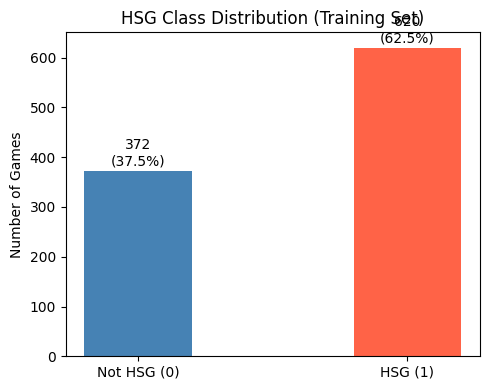

Majority class baseline accuracy: 62.5%


In [285]:
# Class distribution in training set
hsg_counts = train_df['HSG'].value_counts().sort_index()
hsg_pct = train_df['HSG'].value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Not HSG (0)', 'HSG (1)'], hsg_counts.values, color=['steelblue', 'tomato'], width=0.4)
for bar, count, pct in zip(bars, hsg_counts.values, hsg_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{count}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of Games')
ax.set_title('HSG Class Distribution (Training Set)')
plt.tight_layout()
plt.show()

print(f"Majority class baseline accuracy: {hsg_pct.max():.1f}%")

The training set shows a moderate class imbalance, with HSG=1 (high-scoring) being the majority class at roughly 64% of games. This means a naive classifier that always predicts "high-scoring" would achieve ~64% accuracy, setting the baseline any model must exceed. The imbalance also means that standard accuracy alone is insufficient for evaluation, which motivates us to use macro F1 as our primary metric.

## EDA Q1: Do rolling performance averages meaningfully differentiate high-scoring games?

**Rolling averages** determine the averages of the most recent games leading up to a given game, 
and are the primary historical trend features to be used in our models. Understanding whether they actually differ between classes tells us if past performance is a meaningful predictor of an upcoming high-scoring game.

First, let's examine the distributions of all rolling average features: `PPG3`, `FGA3`, `FG%3`, `3PA3`, `3P%3`, `FTA3`, `FT%3`, and `MP3`, split by `HSG` class, to check whether high-scoring and non-high-scoring games show meaningfully different trends in prior performance.

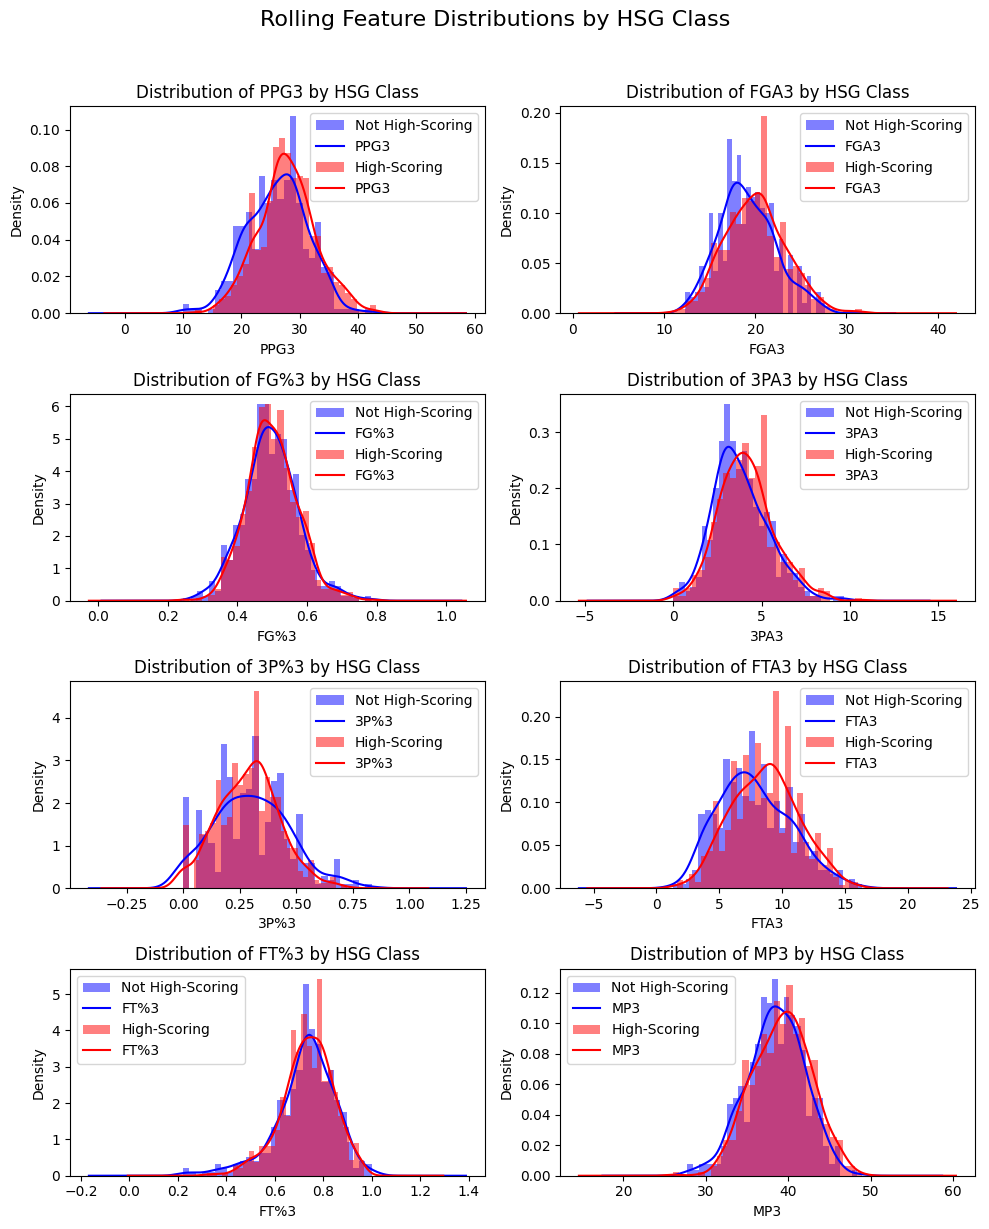

In [286]:
rolling_features = ['PPG3', 'FGA3', 'FG%3', '3PA3', '3P%3', 'FTA3', 'FT%3', 'MP3']

fig, axes = plt.subplots(4, 2, figsize=(10, 12))
axes = axes.flatten()

for i, feature in enumerate(rolling_features):
    for hsg_val, label, color in [(0, 'Not High-Scoring', 'blue'), (1, 'High-Scoring', 'red')]:
        subset = train_df[train_df['HSG'] == hsg_val][feature]
        axes[i].hist(subset, bins=30, alpha=0.5, label=label, color=color, density=True)
        subset.plot.kde(ax=axes[i], color=color)
    axes[i].set_title(f'Distribution of {feature} by HSG Class')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Rolling Feature Distributions by HSG Class', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

From these distributions, we observe that **volume-based features** (i.e., how much he shot or scored) such as `PPG3`, `FGA3`, `FTA3` show the clearest distinction between what games are high-scoring and not, with the high-scoring class consistently shifted toward higher values. **This suggests that LeBron's recent scoring output and shot volume are strong indicators of an upcoming high-scoring game.**

On the other hand, **efficiency-based features** (i.e., how well he shot, not how much he shot) like `FG%3`, `3P%3`, `FT%3` show significant overlap between both classes, which means that recent **shooting percentages are less likely to predict a high-scoring game**. `3PA3` and `MP3` fall in between, with slight separation but substantial overlap.

Overall, if LeBron been taking a lot of shots and scoring a lot lately, that's a stronger signal he'll hit 25+ points. But if he's been shooting at a high percentage lately, that doesn't really tell us much either way.

In [287]:
# Mean of each rolling feature by HSG class
train_df.groupby('HSG')[rolling_features].mean().round(3)

,PPG3,FGA3,FG%3,3PA3,3P%3,FTA3,FT%3,MP3
HSG,,,,,,,,
0,26.121,19.136,0.496,3.799,0.302,7.791,0.726,38.468
1,27.788,20.036,0.501,4.135,0.289,8.645,0.736,39.266


Here we take a look of the mean of each rolling feature separated by the `HSG` class once again. From these values, we can see that the features where `HSG`=1 consistently shows **higher means** than `HSG`=0 are the **volume-based features** (`PPG3`, `FGA3`, `FTA3`) and `MP3`, though the difference in `MP3` is notably smaller than the others. In contrast, **efficiency-based features**  (`FG%3`, `FT%3`, and `3P%3`) show nearly **identical means** across both classes, reinforcing that shooting percentages **do little** to help predict whether a game will be high-scoring.

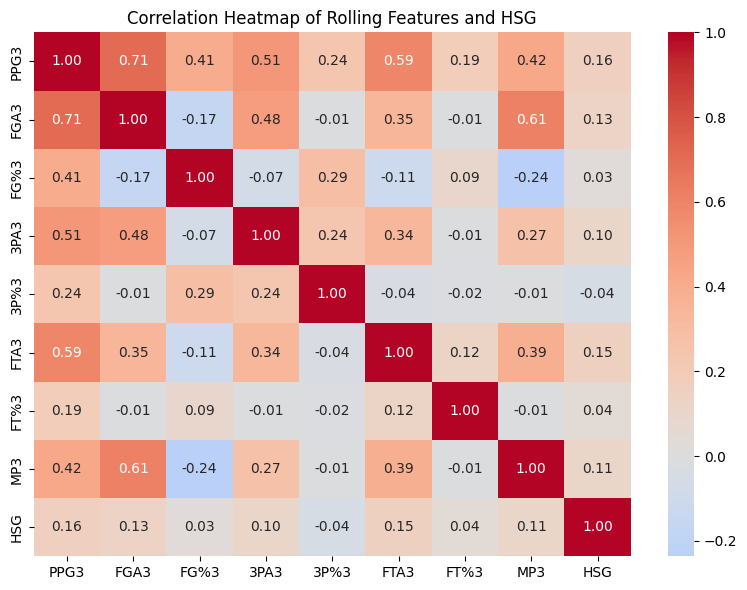

In [288]:
# Correlation heatmap
corr = train_df[['PPG3', 'FGA3', 'FG%3', '3PA3', '3P%3', 'FTA3', 'FT%3', 'MP3', 'HSG']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Rolling Features and HSG")
plt.tight_layout()
plt.show()

The heatmap above shows the correlation between each rolling feature and `HSG`. Looking at the `HSG` row, **all rolling features show relatively low correlations  with the target**, with `PPG3` (0.16) and `FTA3` (0.15) being the strongest. Efficiency-based features like `FG%3`, `FT%3`, and `3P%3` are near zero, confirming they have little to no relationship with `HSG`.

The heatmap also reveals that some features are correlated with each other, notably `PPG3` and `FGA3` (0.71) and `FGA3` and `MP3` (0.61), meaning they carry overlapping information. No single rolling feature strongly predicts `HSG` on its own, which tells us that the model will need to combine multiple features together to make accurate predictions.

## EDA Q2: Does home or away status affect HSG likelihood?

**Home/away status** `Home` is one of the simplest features in our dataset, yet its effect on scoring is not immediately obvious. Examining whether game location produces a consistent difference in HSG rates helps justify its inclusion as a feature in our models.

To answer the second research question, we compute the high-scoring game rate for home and away games separately and visualize the difference using a bar chart. The game counts are included to ensure the comparison is not skewed by unequal sample sizes.

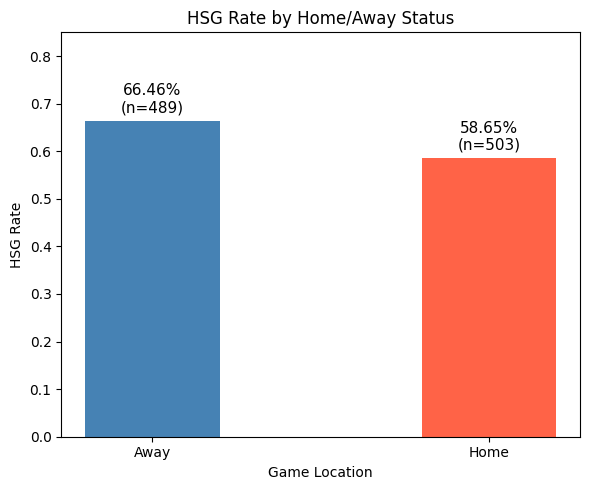

In [289]:
home_stats = train_df.groupby('Home')['HSG'].agg(['mean', 'count']).reset_index()
home_stats.columns = ['Home', 'HSG_Rate', 'Count']
home_stats['Label'] = home_stats['Home'].map({0: 'Away', 1: 'Home'})

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(home_stats['Label'], home_stats['HSG_Rate'], color=['steelblue', 'tomato'], width=0.4)

for bar, (_, row) in zip(bars, home_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{row['HSG_Rate']:.2%}\n(n={int(row['Count'])})", ha='center', va='bottom', fontsize=11)

ax.set_title('HSG Rate by Home/Away Status')
ax.set_xlabel('Game Location')
ax.set_ylabel('HSG Rate')
ax.set_ylim(0, 0.85)
plt.tight_layout()
plt.show()

The bar chart shows that LeBron has a higher high-scoring game rate in away games (66.46%) compared to home games (58.65%), which is counterintuitive as players  generally tend to perform better at home. The sample sizes are balanced (n=489 away, n=503 home), so this difference is not due to unequal game counts. This suggests that home/away status does carry some useful information for `HSG`, with away games being slightly more associated with high-scoring performances.

## EDA Q3: Does LeBron's age affect scoring consistency?

To answer this question, we group LeBron's games into age bins and compute the HSG rate for each group. Since the training set spans roughly 20 years of his career, we use 4 bins of equal width to balance both detail and reliability, and make sure each bin contains enough number of games to produce reliable rates while still capturing meaningful age trends.

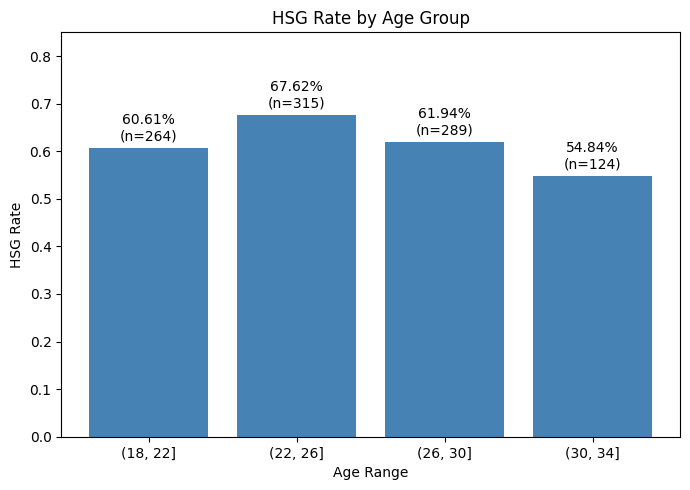

In [290]:
train_df['Age_Bin'] = pd.cut(train_df['Age'], bins=[18, 22, 26, 30, 34, 39])
age_stats = train_df.groupby('Age_Bin', observed=False)['HSG'].agg(['mean', 'count']).reset_index()
age_stats.columns = ['Age_Bin', 'HSG_Rate', 'Count']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(age_stats['Age_Bin'].astype(str), age_stats['HSG_Rate'], color='steelblue')

for bar, (_, row) in zip(bars, age_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{row['HSG_Rate']:.2%}\n(n={int(row['Count'])})", ha='center', va='bottom', fontsize=10)

ax.set_title('HSG Rate by Age Group')
ax.set_xlabel('Age Range')
ax.set_ylabel('HSG Rate')
ax.set_ylim(0, 0.85)
plt.tight_layout()
plt.show()

The bar chart above shows us that LeBron's high-scoring game rate is highest in the 22-26 age range (67.62%) and gradually goes down as he gets older, dropping to 54.84% in the 30-34 range. This shows a mild downward trend in scoring consistency with age, though the differences across bins are not dramatic. The 34-39 age group is absent from the training set as those games fall in the later portion of the dataset, which is reserved for validation and testing.


## Feature Importance Analysis

In this section, we use a Random Forest classifier to compute feature importances on the derived dataset (`LJ_Dataset_DERIV.csv`), giving us a data-driven ranking of which features matter most for predicting whether LeBron has a high-scoring game (`HSG`). Note that this part is purely for exploratory purposes, only meant to guide feature selection.

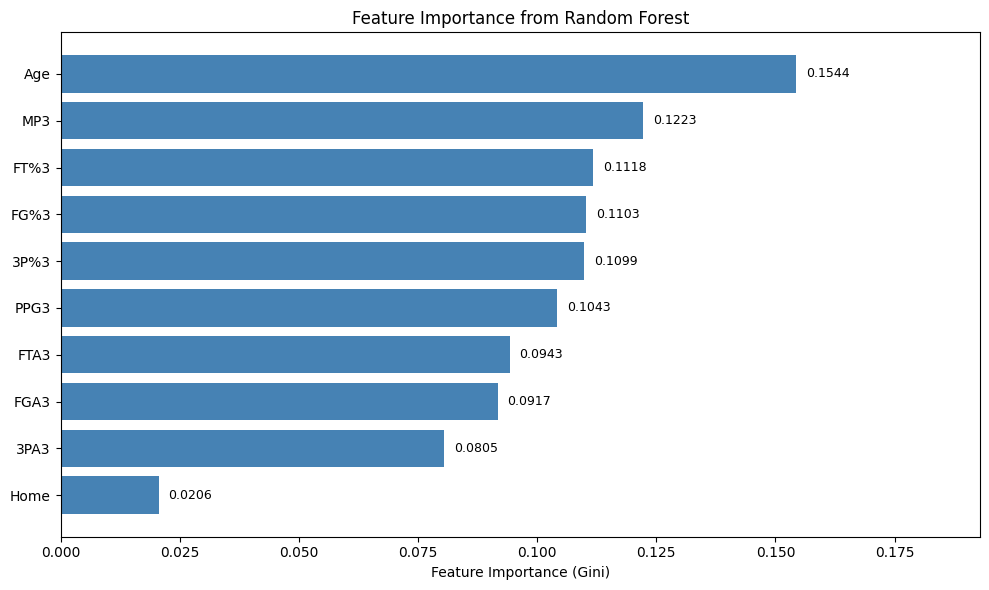


Feature Importance Ranking:
Age     0.154351
MP3     0.122258
FT%3    0.111797
FG%3    0.110294
3P%3    0.109910
PPG3    0.104274
FTA3    0.094271
FGA3    0.091747
3PA3    0.080523
Home    0.020574


In [291]:
feature_cols = [c for c in train_df.columns if c not in ['Date', 'HSG', 'Age_Bin']]
X = train_df[feature_cols]
y = train_df['HSG']

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)

importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(importances.index, importances.values, color='steelblue')

for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importance from Random Forest')
ax.set_xlim(0, importances.max() * 1.25)
plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print(importances.sort_values(ascending=False).to_string())

## Conclusions

Based on the exploratory data analysis conducted across the three research questions, we can draw the following conclusions:

1. **Rolling performance averages** show that volume-based features (`PPG3`, `FGA3`, `FTA3`) are the most informative for predicting `HSG`, as they show the clearest separation between classes. Efficiency-based features (`FG%3`, `FT%3`, `3P%3`) show little to no difference between classes and are unlikely to contribute much predictive value. Additionally, no single rolling feature strongly predicts `HSG` on its own, suggesting the model will need to combine multiple features.

2. **Home/away status** shows a noticeable difference in HSG rates, with LeBron scoring 25 or more points more often in away games than home games in this training split. The sample sizes are balanced enough to treat this as a meaningful pattern.

3. **Age** shows a slight downward trend in HSG rate as LeBron gets older. While the differences across age groups are not drastic, the pattern suggests age carries useful context for scoring consistency.

4. **Feature-importance results** from the Random Forest indicate that volume and recency-driven predictors rank highest, while several efficiency percentages are comparatively weaker.

Overall, the most promising features going into model training are `PPG3`, `FGA3`, `FTA3`, `Home`, and `Age`, while efficiency-based rolling features may contribute less to model performance.

---
# 6. Model 1: Logistic Regression

## Step 1: Load and prepare data
We load the pre-split training, validation, and test datasets. The test file used here is `TEST_LJ_Dataset_w_HSG.csv`, which includes the `HSG` target column for evaluation.

In [292]:
train_df = pd.read_csv('data/splits/TRAIN_LJ_Dataset.csv')
val_df = pd.read_csv('data/splits/VALID_LJ_Dataset.csv')
test_df = pd.read_csv('data/splits/TEST_LJ_Dataset_w_HSG.csv')

train_df.head()

,Date,Age,Home,HSG,PPG3,3PA3,3P%3,FGA3,FG%3,FTA3,FT%3,MP3
0,2003-11-05,18.849315,1,0,18.000,2.667,0.067,16.333,0.440,4.000,0.635,40.783
1,2003-11-07,18.854795,0,0,12.000,2.667,0.067,13.333,0.331,3.333,0.857,40.206
2,2003-11-08,18.857534,1,0,12.667,1.667,0.167,13.667,0.322,3.333,0.952,41.333
3,2003-11-10,18.863014,1,0,15.667,1.333,0.167,16.000,0.379,4.000,0.702,43.111
4,2003-11-12,18.868493,0,0,19.000,1.667,0.500,16.333,0.483,3.667,0.369,40.628


## Step 2: Separate features and target

Before we start training the model, we drop `Date` because it is just an identifier and not a useful feature. `HSG` is separated as the target variable.

In [293]:
drop_cols = ['Date', 'HSG']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['HSG']

X_val = val_df.drop(columns=drop_cols)
y_val = val_df['HSG']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['HSG']

## Step 3: Baseline Logistic Regression (Default Parameters)

Before tuning hyperparameters, we train a logistic regression model with default settings (`C=1`, L2 penalty, no class weight adjustment) using a StandardScaler + SMOTE pipeline. This provides a reference point to quantify how much improvement hyperparameter tuning provides.

StandardScaler standardizes all features to zero mean and unit variance so that the L2 regularization penalty treats every feature equally regardless of its original scale. SMOTE is then applied to the training set to address the ~64/36 class imbalance observed in the EDA by generating synthetic minority-class samples through interpolation. Both steps are placed inside the pipeline to prevent data leakage into the validation and test sets.

BASELINE LOGISTIC REGRESSION (Default Parameters)
  C=1, penalty=l2, class_weight=None, threshold=0.50
  Validation Accuracy: 0.4717
  Validation Macro F1:  0.4709

              precision    recall  f1-score   support

     Not HSG       0.36      0.61      0.45        76
         HSG       0.64      0.40      0.49       136

    accuracy                           0.47       212
   macro avg       0.50      0.50      0.47       212
weighted avg       0.54      0.47      0.48       212



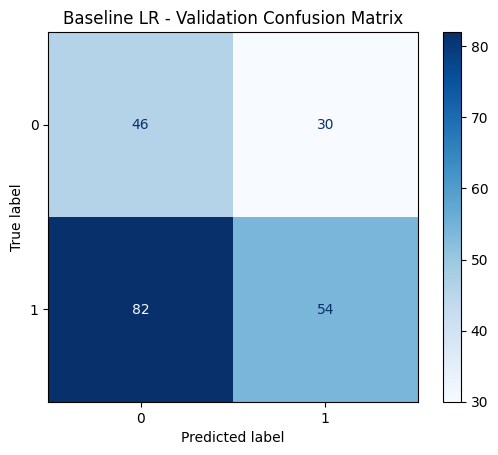

In [294]:
from imblearn.pipeline import Pipeline as ImbPipeline

# Baseline: default LR with StandardScaler + SMOTE
baseline_lr_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(max_iter=10000, random_state=42))
])

baseline_lr_pipeline.fit(X_train, y_train)

y_val_pred_baseline = baseline_lr_pipeline.predict(X_val)
y_val_probs_baseline = baseline_lr_pipeline.predict_proba(X_val)[:, 1]

baseline_acc = accuracy_score(y_val, y_val_pred_baseline)
baseline_f1 = f1_score(y_val, y_val_pred_baseline, average='macro')

print("BASELINE LOGISTIC REGRESSION (Default Parameters)")
print(f"  C=1, penalty=l2, class_weight=None, threshold=0.50")
print(f"  Validation Accuracy: {baseline_acc:.4f}")
print(f"  Validation Macro F1:  {baseline_f1:.4f}")
print()
print(classification_report(y_val, y_val_pred_baseline, target_names=['Not HSG', 'HSG']))

cm_baseline = confusion_matrix(y_val, y_val_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_baseline)
disp.plot(cmap='Blues')
plt.title("Baseline LR - Validation Confusion Matrix")
plt.show()

The baseline logistic regression with default parameters (`C=1`, L2 penalty, no class weight adjustment, threshold 0.50) achieves a validation accuracy of 47.17% and a macro F1 of 0.4709. The confusion matrix reveals that the model misclassifies 82 out of 136 actual high-scoring games as not high-scoring (60.3% false negative rate), meaning SMOTE alone is not enough to correct the class imbalance at the default threshold.

This weak starting point motivates the joint hyperparameter search in the next step, where tuning `C`, penalty type, `class_weight`, and the decision threshold together may recover performance that the default configuration misses.

## Step 4: Define hyperparameter search space

We define the candidate values for each hyperparameter. Instead of tuning `C` alone and then tuning the decision threshold separately, we search over all combinations jointly. This ensures we do not accidentally eliminate a configuration that performs poorly at the default 0.50 threshold but excels at a different one.

The search covers:
- `C`: regularization strength (inverse), ranging from strong to weak regularization.
- `penalty`: the type of regularization applied to the model coefficients (`l1`, `l2`, or `elasticnet`).
- `class_weight`: whether to handle class imbalance through SMOTE (default) or by reweighting the loss function (`balanced`). These two strategies are not used together to avoid double-compensating for the imbalance.
- `threshold`: the probability cutoff for predicting the positive class.

The solver is determined automatically based on the penalty type, since not all solvers support all penalties (`liblinear` for L1, `lbfgs` for L2, `saga` for elasticnet). `max_iter` is fixed at 2000 to guarantee convergence across all configurations.

In [295]:
C_values = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
penalties = ['l1', 'l2', 'elasticnet']
class_weights = [None, 'balanced']
thresholds = np.arange(0.10, 0.91, 0.05)

### Handling class imbalance during hyperparameter tuning

Different strategies are used to handle class imbalance depending on the configuration. When `class_weight='balanced'` is used, the model internally adjusts the importance of each class during training. In this case, SMOTE is not applied to avoid combining two imbalance-handling methods.

When `class_weight=None`, SMOTE is applied within the pipeline to generate synthetic samples for the minority class. This allows us to compare the effectiveness of resampling versus class weighting as separate approaches.

## Step 5: Joint hyperparameter tuning on validation set

For each combination of `C`, `penalty`, and `class_weight`, we build a pipeline that scales the features, optionally applies SMOTE, and trains a logistic regression model. When `class_weight='balanced'` is used, SMOTE is skipped since both address class imbalance and combining them would over-correct.

The combination of hyperparameters that produces the highest macro F1 on the validation set is selected as the final configuration.

In [296]:
results = []
best_model = None
best_config = None
best_f1 = -1

for C, penalty, cw in product(C_values, penalties, class_weights):
    # Set solver and possible l1_ratio values
    if penalty == 'l1':
        solver = 'liblinear'
        l1_ratios = [None]
    elif penalty == 'elasticnet':
        solver = 'saga'
        l1_ratios = [0.25, 0.5, 0.75]
    else:  # l2
        solver = 'lbfgs'
        l1_ratios = [None]

    for l1_ratio in l1_ratios:
        extra = {'l1_ratio': l1_ratio} if penalty == 'elasticnet' else {}

        # Skip SMOTE when class_weight='balanced'
        if cw == 'balanced':
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(
                    C=C,
                    penalty=penalty,
                    solver=solver,
                    class_weight=cw,
                    max_iter=2000,
                    random_state=1,
                    **extra
                ))
            ])
        else:
            model = Pipeline([
                ('scaler', StandardScaler()),
                ('smote', SMOTE(random_state=1)),
                ('clf', LogisticRegression(
                    C=C,
                    penalty=penalty,
                    solver=solver,
                    max_iter=2000,
                    random_state=1,
                    **extra
                ))
            ])

        model.fit(X_train, y_train)
        y_val_probs = model.predict_proba(X_val)[:, 1]

        for threshold in thresholds:
            y_val_pred = (y_val_probs >= threshold).astype(int)
            f1 = f1_score(y_val, y_val_pred, average='macro')
            acc = accuracy_score(y_val, y_val_pred)

            results.append({
                'C': C,
                'penalty': penalty,
                'class_weight': cw,
                'l1_ratio': l1_ratio,
                'threshold': round(threshold, 2),
                'validation_f1_macro': f1,
                'validation_accuracy': acc
            })

            if f1 > best_f1:
                best_f1 = f1
                best_config = {
                    'C': C,
                    'penalty': penalty,
                    'solver': solver,
                    'class_weight': cw,
                    'l1_ratio': l1_ratio,
                    'threshold': round(threshold, 2)
                }
                best_model = model

lr_results_df = pd.DataFrame(results)

print("Best config:", best_config)
print(f"Best Validation Macro F1: {best_f1:.4f}")

Best config: {'C': 0.01, 'penalty': 'elasticnet', 'solver': 'saga', 'class_weight': 'balanced', 'l1_ratio': 0.75, 'threshold': np.float64(0.5)}
Best Validation Macro F1: 0.5158


### Tuning results overview

We display the top configurations ranked by validation macro F1 to see which hyperparameter combinations performed best.

In [297]:
lr_results_df_sorted = lr_results_df.sort_values('validation_f1_macro', ascending=False).reset_index(drop=True)
lr_results_df_sorted.head(20)

,C,penalty,class_weight,l1_ratio,threshold,validation_f1_macro,validation_accuracy
0,0.01,elasticnet,balanced,0.75,0.50,0.515849,0.528302
1,10.00,elasticnet,balanced,0.50,0.45,0.511879,0.584906
2,1.00,elasticnet,balanced,0.25,0.45,0.511879,0.584906
3,10.00,l2,balanced,NaN,0.45,0.511879,0.584906
4,1.00,l2,balanced,NaN,0.45,0.511879,0.584906
...,...,...,...,...,...,...,...
15,100.00,elasticnet,balanced,0.50,0.45,0.508428,0.580189
16,100.00,elasticnet,balanced,0.75,0.45,0.508428,0.580189
17,1000.00,elasticnet,balanced,0.75,0.45,0.508428,0.580189
18,1.00,elasticnet,balanced,0.50,0.45,0.508428,0.580189


## Step 6: Evaluate on validation set

We apply the best configuration (hyperparameters and threshold) to the validation set and display the detailed classification metrics. Since this is the same validation set used for tuning, these numbers are not an independent estimate of generalization. The unbiased evaluation comes later on the test set.

In [298]:
y_val_probs = best_model.predict_proba(X_val)[:, 1]
y_val_pred = (y_val_probs >= best_config['threshold']).astype(int)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_f1_macro = f1_score(y_val, y_val_pred, average='macro')

print("Best Config:", best_config)
print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print(f"Validation Macro F1: {val_f1_macro:.4f}")
print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))

Best Config: {'C': 0.01, 'penalty': 'elasticnet', 'solver': 'saga', 'class_weight': 'balanced', 'l1_ratio': 0.75, 'threshold': np.float64(0.5)}

Validation Accuracy: 0.5283
Validation Macro F1: 0.5158

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.38      0.51      0.44        76
           1       0.66      0.54      0.59       136

    accuracy                           0.53       212
   macro avg       0.52      0.52      0.52       212
weighted avg       0.56      0.53      0.54       212



This joint search selected an elastic net logistic regression model with `C=0.01`, `class_weight='balanced`, and `l1_ratio=0.75`, along with a decision threshold of approximately 0.5. The relatively small value of `C` tells us that the model needs heavier regularization, while the high `l1_ratio` indicates that the model benefits from a stronger L1 component, encouraging sparsity in the coefficients that were learned.

Since the best-performing configuration used `class_weight='balanced'` rather than SMOTE in this search space, we can conclude that reweighting was more effective than synthetic oversampling for handling class imbalance for this dataset.

## Step 7: Validation Confusion Matrix
We plot the confusion matrix to see where the model is making mistakes. This is more informative than a single accuracy number because it shows whether the model is biased toward one class, and whether the errors are concentrated in false positives or false negatives.

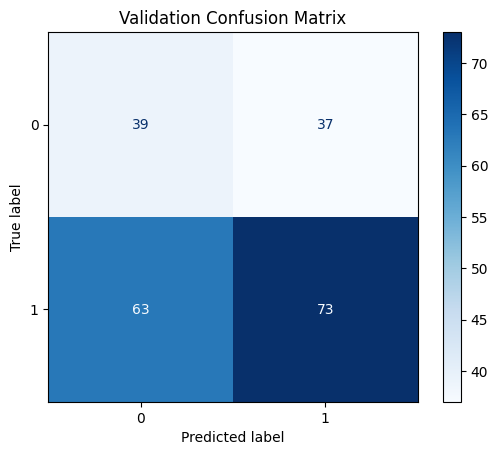

In [299]:
cm_val = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_val)
disp.plot(cmap='Blues')
plt.title("Validation Confusion Matrix")
plt.show()

The confusion matrix shows that the model correctly classifies 39 non-high-scoring games and 73 high-scoring games. However, it misclassifies 37 non-high-scoring games as high-scoring and 63 high-scoring games as non-high-scoring. This shows that the model struggles to clearly separate the two classes as errors occur in both directions. While it is able to identify some high-scoring games, a significant number are still missed, and many non-high-scoring games are incorrectly predicted as high-scoring. Overall, the confusion matrix reflects moderate performance with no strong power in correctly identifying either class.

### Threshold Curve
To understand how sensitive the model is to the decision threshold, we plot macro F1 across all thresholds using the best hyperparameter configuration. A sharp peak suggests the model's probabilities are well-separated between classes, while a flat curve indicates weak separation.

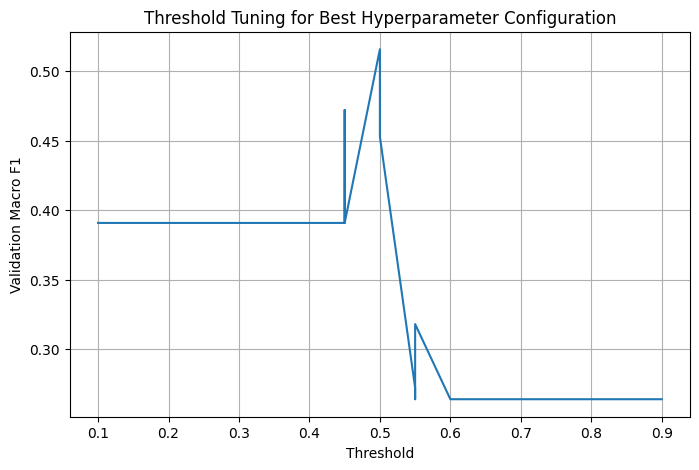

Peak threshold: 0.5


In [300]:
best_hp_results = lr_results_df[
    (lr_results_df['C'] == best_config['C']) &
    (lr_results_df['penalty'] == best_config['penalty']) &
    (lr_results_df['class_weight'] == best_config['class_weight'])
].sort_values('threshold')

plt.figure(figsize=(8, 5))
plt.plot(best_hp_results['threshold'], best_hp_results['validation_f1_macro'])
plt.xlabel("Threshold")
plt.ylabel("Validation Macro F1")
plt.title("Threshold Tuning for Best Hyperparameter Configuration")
plt.grid(True)
plt.show()

print(f"Peak threshold: {best_config['threshold']}")

The threshold curve shows that performance is fairly stable at lower thresholds (0.1–0.45), meaning the model behaves similarly when predicting more positives. The macro F1 score peaks around 0.50, which gives the best balance between precision and recall. After this point, performance drops quickly, which tells us that higher thresholds make the model too conservative and cause it to miss a lot of positive cases. Overall, the model is quite sensitive to the threshold and performs best near 0.50.

## Step 8: Final evaluation on test set
We apply the best configuration to the test set to get our final, unbiased performance estimate. This reflects how the model would perform on completely new data that was never used for training, hyperparameter tuning, or threshold selection.

In [301]:
y_test_probs = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_probs >= best_config['threshold']).astype(int)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')

# Store explicit Model 1 handoff variables for Section 8
y_test_lr = y_test.copy()
y_test_pred_lr = y_test_pred
lr_test_acc = test_accuracy
lr_test_f1 = test_f1_macro

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Macro F1: {test_f1_macro:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred))

Test Accuracy: 0.5514
Test Macro F1: 0.5383

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.40      0.54      0.46        76
           1       0.69      0.56      0.62       138

    accuracy                           0.55       214
   macro avg       0.54      0.55      0.54       214
weighted avg       0.59      0.55      0.56       214



On the test set, the model performs moderately and achieves an accuracy of 0.55 and a macro F1 score of 0.54. It performs better on predicting high-scoring games (class 1), with higher precision (0.69) and F1 score (0.62), compared to non-high-scoring games (class 0).

On the other hand, performance on class 0 remains weaker as the model still struggles to correctly identify non-high-scoring games. Overall, the model shows a slight bias toward predicting high-scoring outcomes, but maintains a relatively balanced performance across both classes.

### Confusion matrix on test set

We plot the test set confusion matrix to visualize the model's final classification performance.

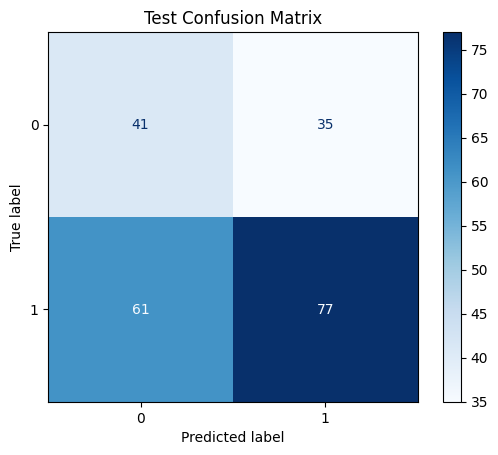

In [302]:
cm_test = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test)
disp.plot(cmap='Blues')
plt.title("Test Confusion Matrix")
plt.show()

This confusion matrix shows that it was able to correctly identify 41 non-high scoring games and 77 high-scoring games.  However, it misclassified 35 non-high-scoring games as high-scoring and 61 high-scoring games as non-high-scoring.

## Conclusions

Logistic regression was not able to reliably predict whether LeBron James would have a high-scoring game. The best configuration (`C = 0.01`, `l1_ratio=0.75`, `class_weight='balanced'`, threshold of 0.5) achieved a test accuracy of 55% and a macro F1 of 0.54.

Here are our observations:

1. **`class_weight='balanced'` outperformed SMOTE.** Loss reweighting handled class imbalance more effectively than synthetic oversampling. The baseline SMOTE pipeline scored a validation macro F1 of 0.47, and the best tuned configuration using `class_weight='balanced'` improved this to 0.51.
2. **Elastic net performed the best out of all penalties** The best combination of hyperparameters favored a strong L1 component, suggesting that some level of sparsity helps, but the overall performance gain remains limited.
3. **Class 0 remained hard to predict.** The model consistently performs bad on non-high-scoring games, which means the features don't separate the two classes well enough.
4. **Threshold tuning showed a clear peak.** The macro F1 score peaked around a threshold of 0.50 (though improvements are still modest).
5. **Validation and test performance were consistent.** Validation macro F1 and test macro F1 are close, which means that the model generalizes similarly to unseen data and is not overfitting heavily.

Overall, the current set of features is still not enough to predict under a linear model.

---
# 7. Model 2: K-Nearest Neighbors

## Data Preprocessing

### Load the data

In [303]:
# Reuse already-loaded splits when available; otherwise load from CSV files.
if {'train_df', 'val_df', 'test_df'}.issubset(locals()):
    print('Using existing train/val/test dataframes from earlier notebook cells.')
else:
    train_df = pd.read_csv('data/splits/TRAIN_LJ_Dataset.csv')
    val_df = pd.read_csv('data/splits/VALID_LJ_Dataset.csv')
    test_df = pd.read_csv('data/splits/TEST_LJ_Dataset.csv')
    print('Loaded train/val/test dataframes from CSV files.')

train_df.head()

Using existing train/val/test dataframes from earlier notebook cells.


,Date,Age,Home,HSG,PPG3,3PA3,3P%3,FGA3,FG%3,FTA3,FT%3,MP3
0,2003-11-05,18.849315,1,0,18.000,2.667,0.067,16.333,0.440,4.000,0.635,40.783
1,2003-11-07,18.854795,0,0,12.000,2.667,0.067,13.333,0.331,3.333,0.857,40.206
2,2003-11-08,18.857534,1,0,12.667,1.667,0.167,13.667,0.322,3.333,0.952,41.333
3,2003-11-10,18.863014,1,0,15.667,1.333,0.167,16.000,0.379,4.000,0.702,43.111
4,2003-11-12,18.868493,0,0,19.000,1.667,0.500,16.333,0.483,3.667,0.369,40.628


### Separate features and target

We drop `Date` as it is just an identifier and not a useful feature for the model.
`HSG` is separated as the target variable.

In [304]:
X_train = train_df.drop(columns=['Date', 'HSG'])
y_train = train_df['HSG']
X_val = val_df.drop(columns=['Date', 'HSG'])
y_val = val_df['HSG']
X_test = test_df.drop(columns=['Date', 'HSG'])
y_test = test_df['HSG']

X_train_knn = X_train
y_train_knn = y_train
X_val_knn = X_val
y_val_knn = y_val
X_test_knn = X_test
y_test_knn = y_test

print(f"Dataset Information:")
print(f"  Train: {len(y_train_knn)} samples | Val: {len(y_val_knn)} samples | Test: {len(y_test_knn)} samples")
print(f"  Features: {X_train_knn.shape[1]}")
print(f"  Feature names: {list(X_train_knn.columns)}")
print(f"  Class distribution: {y_train_knn.value_counts().to_dict()}")

Dataset Information:
  Train: 992 samples | Val: 212 samples | Test: 214 samples
  Features: 10
  Feature names: ['Age', 'Home', 'PPG3', '3PA3', '3P%3', 'FGA3', 'FG%3', 'FTA3', 'FT%3', 'MP3']
  Class distribution: {1: 620, 0: 372}


### StandardScaler

Scaling is a **hard requirement** for KNN. It relies on distance calculations
between data points, so features with larger scales would dominate the distance
metric and effectively drown out smaller-scaled features. `StandardScaler`
transforms each feature to have mean 0 and standard deviation 1.

In [305]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Scaling completed - shape: {X_train_scaled.shape}")

Scaling completed - shape: (992, 10)


### PCA Dimensionality Reduction

KNN suffers from the curse of dimensionality — in high-dimensional spaces,
distances between points converge, making it hard to distinguish neighbors.
We use PCA to check how many components are needed to retain 95% of the
variance. If the feature count is already low, we skip dimensionality reduction.

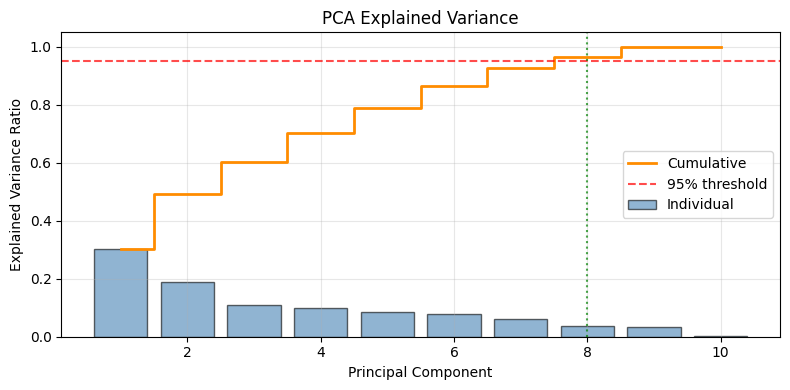

Components needed for 95% variance: 8


In [306]:
pca_full = PCA().fit(X_train_scaled)
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(cumulative_var) + 1), pca_full.explained_variance_ratio_,
       alpha=0.6, label='Individual', color='steelblue', edgecolor='black')
ax.step(range(1, len(cumulative_var) + 1), cumulative_var, where='mid',
        label='Cumulative', color='darkorange', linewidth=2)
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.7, label='95% threshold')
ax.axvline(x=n_components_95, color='green', linestyle=':', alpha=0.7)
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Explained Variance')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Components needed for 95% variance: {n_components_95}")

In [307]:
if n_components_95 < X_train_scaled.shape[1]:
    pca = PCA(n_components=n_components_95)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_val_pca = pca.transform(X_val_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    X_train_final = X_train_pca
    X_val_final = X_val_pca
    X_test_final = X_test_pca
else:
    X_train_final = X_train_scaled
    X_val_final = X_val_scaled
    X_test_final = X_test_scaled

print(f"Final feature matrix shape: {X_train_final.shape}")

Final feature matrix shape: (992, 8)


## Step 1: Eval on Validation Set (Baseline)
Train a baseline KNN model on the original training set and evaluate on the validation set.

In [308]:
baseline_model = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski')
baseline_model.fit(X_train_final, y_train)

y_val_pred_baseline = baseline_model.predict(X_val_final)
baseline_acc = accuracy_score(y_val, y_val_pred_baseline)
baseline_f1 = f1_score(y_val, y_val_pred_baseline, average='macro')

print('BASELINE VALIDATION RESULTS (No SMOTE)')
print(f'Accuracy: {baseline_acc:.4f} ({baseline_acc*100:.2f}%)')
print(f'F1 Score: {baseline_f1:.4f} ({baseline_f1*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_baseline,
                            target_names=['Not High-Scoring', 'High-Scoring']))

BASELINE VALIDATION RESULTS (No SMOTE)
Accuracy: 0.5472 (54.72%)
F1 Score: 0.5048 (50.48%)

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.36      0.36      0.36        76
    High-Scoring       0.64      0.65      0.65       136

        accuracy                           0.55       212
       macro avg       0.50      0.50      0.50       212
    weighted avg       0.54      0.55      0.55       212



## Step 2: Hyperparameter Tuning (No SMOTE)
Use a validation-set sweep to select the best KNN configuration instead of fixing values manually.

In [309]:
from itertools import product

# Sweep KNN settings on train -> validate (no SMOTE)
k_values = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25]
weight_options = ['uniform', 'distance']
metric_options = ['euclidean', 'manhattan']

knn_no_smote_results = []

for k, w, m in product(k_values, weight_options, metric_options):
    model = KNeighborsClassifier(n_neighbors=k, weights=w, metric=m)
    model.fit(X_train_final, y_train)
    y_val_pred = model.predict(X_val_final)

    knn_no_smote_results.append({
        'n_neighbors': k,
        'weights': w,
        'metric': m,
        'val_f1_macro': f1_score(y_val, y_val_pred, average='macro'),
        'val_accuracy': accuracy_score(y_val, y_val_pred),
    })

knn_no_smote_df = pd.DataFrame(knn_no_smote_results).sort_values(
    by=['val_f1_macro', 'val_accuracy'],
    ascending=False
).reset_index(drop=True)

best_row = knn_no_smote_df.iloc[0]
best_params_no_smote = {
    'n_neighbors': int(best_row['n_neighbors']),
    'weights': best_row['weights'],
    'metric': best_row['metric']
}

print('Top 10 no-SMOTE configurations (ranked by Macro F1, then Accuracy):')
display(knn_no_smote_df.head(10).round(4))

Top 10 no-SMOTE configurations (ranked by Macro F1, then Accuracy):


,n_neighbors,weights,metric,val_f1_macro,val_accuracy
0,15,distance,euclidean,0.5599,0.6274
1,15,uniform,euclidean,0.5447,0.6179
2,9,distance,euclidean,0.5410,0.5896
3,7,uniform,euclidean,0.5373,0.5708
4,7,distance,euclidean,0.5373,0.5708
5,9,uniform,euclidean,0.5373,0.5849
6,13,uniform,euclidean,0.5308,0.5849
7,11,distance,euclidean,0.5272,0.5802
8,11,uniform,euclidean,0.5235,0.5755
9,13,distance,euclidean,0.5235,0.5755


In [310]:
print('Selected best no-SMOTE configuration from tuning:')
print(best_params_no_smote)
print(
    f"Validation Macro F1: {best_row['val_f1_macro']:.4f} | "
    f"Validation Accuracy: {best_row['val_accuracy']:.4f}"
)
print('\nThis is how n_neighbors was chosen (not fixed by hand).')

Selected best no-SMOTE configuration from tuning:
{'n_neighbors': 15, 'weights': 'distance', 'metric': 'euclidean'}
Validation Macro F1: 0.5599 | Validation Accuracy: 0.6274

This is how n_neighbors was chosen (not fixed by hand).


## Step 3: Eval on Validation Set (Best Config from Step 2, No SMOTE)
Train using the best no-SMOTE hyperparameters selected in Step 2 and evaluate on the validation set.

VALIDATION RESULTS (Best config from Step 2, No SMOTE)
Using params: {'n_neighbors': 15, 'weights': 'distance', 'metric': 'euclidean'}
Accuracy: 0.6274 (62.74%)
F1 Score: 0.5599 (55.99%)

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.47      0.33      0.39        76
    High-Scoring       0.68      0.79      0.73       136

        accuracy                           0.63       212
       macro avg       0.58      0.56      0.56       212
    weighted avg       0.60      0.63      0.61       212



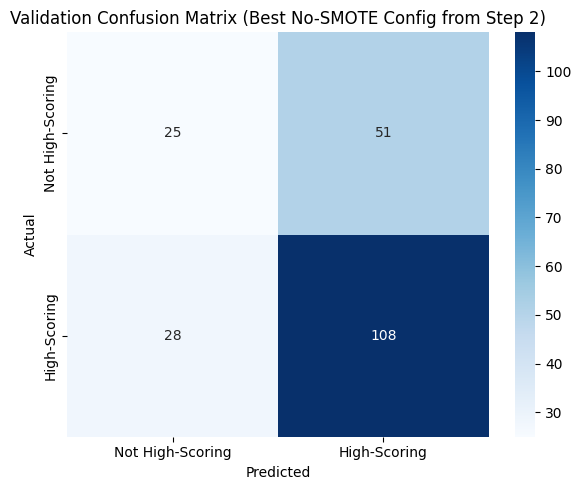

In [311]:
tuned_model_no_smote = KNeighborsClassifier(**best_params_no_smote)
tuned_model_no_smote.fit(X_train_final, y_train)

y_val_pred_tuned = tuned_model_no_smote.predict(X_val_final)
acc_val_tuned = accuracy_score(y_val, y_val_pred_tuned)
f1_val_tuned = f1_score(y_val, y_val_pred_tuned, average='macro')
cm_val_tuned = confusion_matrix(y_val, y_val_pred_tuned)

print('VALIDATION RESULTS (Best config from Step 2, No SMOTE)')
print(f'Using params: {best_params_no_smote}')
print(f'Accuracy: {acc_val_tuned:.4f} ({acc_val_tuned*100:.2f}%)')
print(f'F1 Score: {f1_val_tuned:.4f} ({f1_val_tuned*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_tuned,
                            target_names=['Not High-Scoring', 'High-Scoring']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_val_tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High-Scoring', 'High-Scoring'],
            yticklabels=['Not High-Scoring', 'High-Scoring'])
plt.title('Validation Confusion Matrix (Best No-SMOTE Config from Step 2)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 4: Apply SMOTE to Training Set

In [312]:
smote = SMOTE(random_state=1)
X_train_sm, y_train_sm = smote.fit_resample(X_train_final, y_train)

print(f'Train before SMOTE: {y_train.value_counts().to_dict()}')
print(f'Train after SMOTE:  {y_train_sm.value_counts().to_dict()}')

Train before SMOTE: {1: 620, 0: 372}
Train after SMOTE:  {0: 620, 1: 620}


## Step 5: Retrain on SMOTE Data Using Step-2 Best Params

In [313]:
smote_model_initial = KNeighborsClassifier(**best_params_no_smote)
smote_model_initial.fit(X_train_sm, y_train_sm)

print('Initial SMOTE model trained with the best no-SMOTE params from Step 2:')
print(best_params_no_smote)

Initial SMOTE model trained with the best no-SMOTE params from Step 2:
{'n_neighbors': 15, 'weights': 'distance', 'metric': 'euclidean'}


## Step 6: Eval SMOTE Model on Validation Set

VALIDATION RESULTS (Initial SMOTE Model)
Accuracy: 0.5236 (52.36%)
F1 Score: 0.5235 (52.35%)

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.41      0.71      0.52        76
    High-Scoring       0.72      0.42      0.53       136

        accuracy                           0.52       212
       macro avg       0.56      0.56      0.52       212
    weighted avg       0.61      0.52      0.53       212



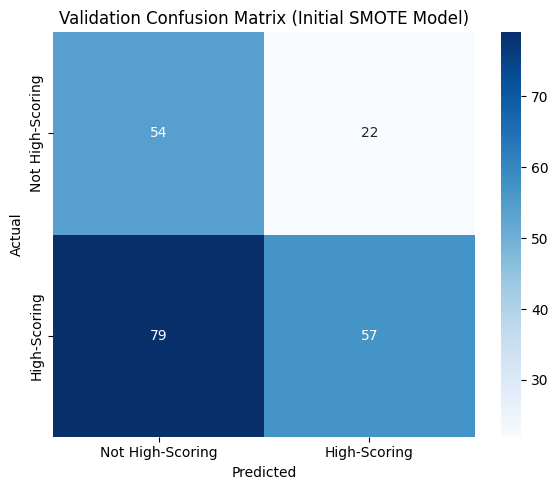

In [314]:
y_val_pred_smote_initial = smote_model_initial.predict(X_val_final)
acc_val_smote_initial = accuracy_score(y_val, y_val_pred_smote_initial)
f1_val_smote_initial = f1_score(y_val, y_val_pred_smote_initial, average='macro')
cm_val_smote_initial = confusion_matrix(y_val, y_val_pred_smote_initial)

print('VALIDATION RESULTS (Initial SMOTE Model)')
print(f'Accuracy: {acc_val_smote_initial:.4f} ({acc_val_smote_initial*100:.2f}%)')
print(f'F1 Score: {f1_val_smote_initial:.4f} ({f1_val_smote_initial*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_smote_initial,
                            target_names=['Not High-Scoring', 'High-Scoring']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_val_smote_initial, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High-Scoring', 'High-Scoring'],
            yticklabels=['Not High-Scoring', 'High-Scoring'])
plt.title('Validation Confusion Matrix (Initial SMOTE Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 7: Hyperparameter Tuning (With SMOTE)

In [315]:
# Sweep KNN settings on SMOTE-resampled TRAIN -> validate
knn_smote_results = []

for k, w, m in product(k_values, weight_options, metric_options):
    model = KNeighborsClassifier(n_neighbors=k, weights=w, metric=m)
    model.fit(X_train_sm, y_train_sm)
    y_val_pred = model.predict(X_val_final)

    knn_smote_results.append({
        'n_neighbors': k,
        'weights': w,
        'metric': m,
        'val_f1_macro': f1_score(y_val, y_val_pred, average='macro'),
        'val_accuracy': accuracy_score(y_val, y_val_pred),
    })

knn_smote_df = pd.DataFrame(knn_smote_results).sort_values(
    by=['val_f1_macro', 'val_accuracy'],
    ascending=False
).reset_index(drop=True)

best_row_smote = knn_smote_df.iloc[0]
best_params_smote = {
    'n_neighbors': int(best_row_smote['n_neighbors']),
    'weights': best_row_smote['weights'],
    'metric': best_row_smote['metric']
}

print('Top 10 SMOTE configurations (ranked by Macro F1, then Accuracy):')
display(knn_smote_df.head(10).round(4))
print('\nSelected best SMOTE configuration:')
print(best_params_smote)
print(
    f"Validation Macro F1: {best_row_smote['val_f1_macro']:.4f} | "
    f"Validation Accuracy: {best_row_smote['val_accuracy']:.4f}"
)

Top 10 SMOTE configurations (ranked by Macro F1, then Accuracy):


,n_neighbors,weights,metric,val_f1_macro,val_accuracy
0,9,uniform,euclidean,0.5374,0.5377
1,9,distance,euclidean,0.5374,0.5377
2,7,distance,manhattan,0.5351,0.5377
3,3,uniform,euclidean,0.5317,0.5377
4,3,distance,euclidean,0.5317,0.5377
5,7,uniform,euclidean,0.5276,0.5283
6,7,uniform,manhattan,0.5262,0.5283
7,15,distance,euclidean,0.5235,0.5236
8,7,distance,euclidean,0.5182,0.5189
9,9,distance,manhattan,0.5168,0.5189



Selected best SMOTE configuration:
{'n_neighbors': 9, 'weights': 'uniform', 'metric': 'euclidean'}
Validation Macro F1: 0.5374 | Validation Accuracy: 0.5377


## Step 8: Retrain the Final SMOTE Model

In [316]:
# Candidate A: best SMOTE configuration trained on SMOTE-resampled TRAIN only
candidate_a_params = best_params_smote
candidate_a_model = KNeighborsClassifier(**candidate_a_params)
candidate_a_model.fit(X_train_sm, y_train_sm)
a_val_proba = candidate_a_model.predict_proba(X_val_final)[:, 1]

# Candidate B: best no-SMOTE configuration trained on original TRAIN only
candidate_b_params = best_params_no_smote
candidate_b_model = KNeighborsClassifier(**candidate_b_params)
candidate_b_model.fit(X_train_final, y_train)
b_val_proba = candidate_b_model.predict_proba(X_val_final)[:, 1]

thresholds = np.arange(0.20, 0.701, 0.01)

best_a = {'f1': -1, 'threshold': 0.5}
best_b = {'f1': -1, 'threshold': 0.5}

for thr in thresholds:
    y_a = (a_val_proba >= thr).astype(int)
    y_b = (b_val_proba >= thr).astype(int)
    f1_a = f1_score(y_val, y_a, average='macro')
    f1_b = f1_score(y_val, y_b, average='macro')
    if f1_a > best_a['f1']:
        best_a = {'f1': f1_a, 'threshold': float(thr)}
    if f1_b > best_b['f1']:
        best_b = {'f1': f1_b, 'threshold': float(thr)}

if best_a['f1'] >= best_b['f1']:
    final_selected_params = candidate_a_params
    final_selected_threshold_from_val = best_a['threshold']
    final_selected_label = 'SMOTE-retuned model'

    final_smote_val_model = KNeighborsClassifier(**final_selected_params)
    final_smote_val_model.fit(X_train_sm, y_train_sm)

    # Keep test training on TRAIN only to avoid validation leakage.
    final_smote_test_model = KNeighborsClassifier(**final_selected_params)
    final_smote_test_model.fit(X_train_sm, y_train_sm)

    train_dist_used = y_train_sm.value_counts().to_dict()
else:
    final_selected_params = candidate_b_params
    final_selected_threshold_from_val = best_b['threshold']
    final_selected_label = 'No-SMOTE tuned model'

    final_smote_val_model = KNeighborsClassifier(**final_selected_params)
    final_smote_val_model.fit(X_train_final, y_train)

    # Keep test training on TRAIN only to avoid validation leakage.
    final_smote_test_model = KNeighborsClassifier(**final_selected_params)
    final_smote_test_model.fit(X_train_final, y_train)

    train_dist_used = y_train.value_counts().to_dict()

# Use the validation-optimized threshold
final_operating_threshold = final_selected_threshold_from_val

print('Final model selection completed.')
print(f'Selected model: {final_selected_label}')
print(f'Selected params: {final_selected_params}')
print(f'Validation-optimized threshold: {final_operating_threshold:.2f}')
print(f'Training class distribution used: {train_dist_used}')

Final model selection completed.
Selected model: No-SMOTE tuned model
Selected params: {'n_neighbors': 15, 'weights': 'distance', 'metric': 'euclidean'}
Validation-optimized threshold: 0.50
Training class distribution used: {1: 620, 0: 372}


## Step 9: Evaluate the Final SMOTE Model on Validation Set

FINAL SMOTE VALIDATION RESULTS (Operating Threshold)
Operating threshold: 0.50
Accuracy: 0.6274 (62.74%)
F1 Score: 0.5599 (55.99%)

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.47      0.33      0.39        76
    High-Scoring       0.68      0.79      0.73       136

        accuracy                           0.63       212
       macro avg       0.58      0.56      0.56       212
    weighted avg       0.60      0.63      0.61       212



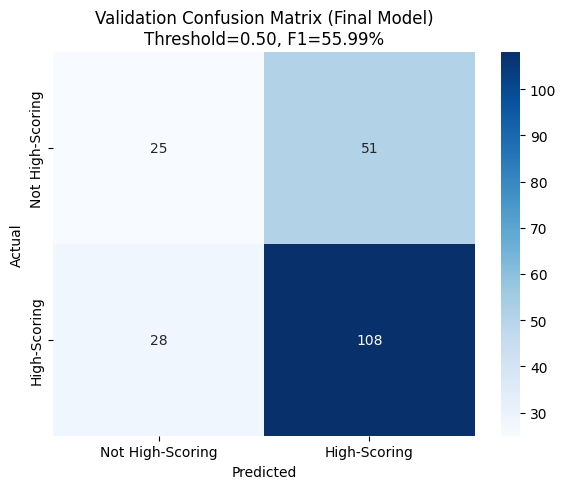

In [317]:
y_val_proba_final_smote = final_smote_val_model.predict_proba(X_val_final)[:, 1]
y_val_pred_final_smote = (y_val_proba_final_smote >= final_operating_threshold).astype(int)
acc_val_final_smote = accuracy_score(y_val, y_val_pred_final_smote)
f1_val_final_smote = f1_score(y_val, y_val_pred_final_smote, average='macro')
cm_val_final_smote = confusion_matrix(y_val, y_val_pred_final_smote)

print('FINAL SMOTE VALIDATION RESULTS (Operating Threshold)')
print(f'Operating threshold: {final_operating_threshold:.2f}')
print(f'Accuracy: {acc_val_final_smote:.4f} ({acc_val_final_smote*100:.2f}%)')
print(f'F1 Score: {f1_val_final_smote:.4f} ({f1_val_final_smote*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_val, y_val_pred_final_smote,
                            target_names=['Not High-Scoring', 'High-Scoring']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_val_final_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High-Scoring', 'High-Scoring'],
            yticklabels=['Not High-Scoring', 'High-Scoring'])
plt.title(f'Validation Confusion Matrix (Final Model)\nThreshold={final_operating_threshold:.2f}, F1={f1_val_final_smote*100:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## Step 10: Final Evaluate the Final Model on the Test Set

FINAL TEST RESULTS (Final Model, Operating Threshold)
Selected model: No-SMOTE tuned model
Operating threshold: 0.50
Accuracy: 0.5654 (56.54%)
F1 Score: 0.5150 (51.50%)

Classification Report:
                  precision    recall  f1-score   support

Not High-Scoring       0.38      0.34      0.36        76
    High-Scoring       0.66      0.69      0.67       138

        accuracy                           0.57       214
       macro avg       0.52      0.52      0.51       214
    weighted avg       0.56      0.57      0.56       214



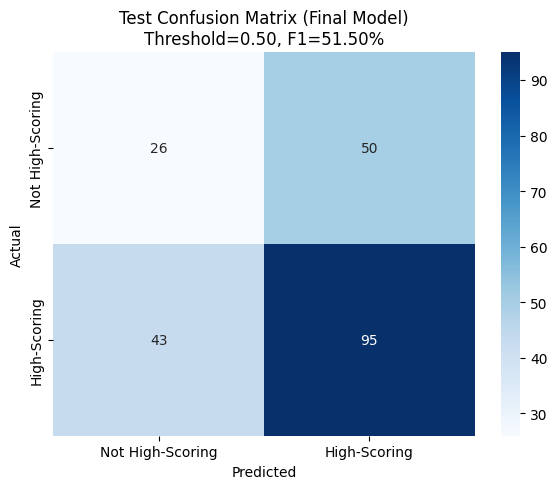


Section 8 handoff updated: y_test_knn, y_test_pred_knn, knn_test_f1, knn_test_acc


In [318]:
y_test_proba_final_smote = final_smote_test_model.predict_proba(X_test_final)[:, 1]
y_test_pred_final_smote = (y_test_proba_final_smote >= final_operating_threshold).astype(int)
acc_test_final_smote = accuracy_score(y_test, y_test_pred_final_smote)
f1_test_final_smote = f1_score(y_test, y_test_pred_final_smote, average='macro')
cm_test_final_smote = confusion_matrix(y_test, y_test_pred_final_smote)

y_test_knn = y_test
y_test_pred_knn = y_test_pred_final_smote
knn_test_f1 = f1_test_final_smote
knn_test_acc = acc_test_final_smote

print('=' * 60)
print('FINAL TEST RESULTS (Final Model, Operating Threshold)')
print('=' * 60)
print(f'Selected model: {final_selected_label}')
print(f'Operating threshold: {final_operating_threshold:.2f}')
print(f'Accuracy: {acc_test_final_smote:.4f} ({acc_test_final_smote*100:.2f}%)')
print(f'F1 Score: {f1_test_final_smote:.4f} ({f1_test_final_smote*100:.2f}%)')
print('\nClassification Report:')
print(classification_report(y_test, y_test_pred_final_smote,
                            target_names=['Not High-Scoring', 'High-Scoring']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_test_final_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not High-Scoring', 'High-Scoring'],
            yticklabels=['Not High-Scoring', 'High-Scoring'])
plt.title(f'Test Confusion Matrix (Final Model)\nThreshold={final_operating_threshold:.2f}, F1={f1_test_final_smote*100:.2f}%')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print('\nSection 8 handoff updated: y_test_knn, y_test_pred_knn, knn_test_f1, knn_test_acc')

## Conclusions

We used K-Nearest Neighbors (KNN) to predict whether LeBron James would have a high-scoring game (HSG). The selected model (k=15, distance-weighted, Euclidean) was chosen via validation-based comparison, achieving a test accuracy of 56.54% and a macro F1-score of 0.5150.

Key observations from our analysis:

1. Generalization Gap: The model showed a notable performance drop from validation (62.74% accuracy) to testing (56.54% accuracy), suggesting difficulty in generalizing to unseen game data.
2. Class Imbalance Impact: Despite tuning, the model struggled with class separation. While the model correctly identified high-scoring games more frequently, "Not High-Scoring" games remained difficult to isolate.
3. Predictive Limitations: Even with optimized distance-weighting and a threshold of 0.50, the KNN boundaries showed significant overlap between classes.
4. Neighborhood Sensitivity: The results indicate that distance-based neighborhoods in the current feature space are not sufficiently distinct to provide high-precision classification.

Overall, while KNN provides a baseline for player performance forecasting, the results suggest that the current features have limited predictive power for stable, balanced performance under a distance-based model.

---
# 8. Model 3: Neural Network

This section trains a binary neural network classifier using custom modules (`nn_dataset.py`, `nn_model.py`, `nn_dataLoader.py`, `nn_tuner.py`).

## Step 1: Set Random Seed and Load Data

In [319]:
SEED = 610
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

train_path = 'data/splits/TRAIN_LJ_Dataset.csv'
valid_path = 'data/splits/VALID_LJ_Dataset.csv'
test_path = 'data/splits/TEST_LJ_Dataset.csv'

splits = load_tabular_splits(train_path, valid_path, test_path)

print("X_train:", splits.X_train.shape, "y_train:", splits.y_train.shape)
print("X_valid:", splits.X_valid.shape, "y_valid:", splits.y_valid.shape)
print("X_test :", splits.X_test.shape, "y_test :", splits.y_test.shape)

X_train: (992, 11) y_train: (992,)
X_valid: (212, 11) y_valid: (212,)
X_test : (214, 11) y_test : (214,)


## Step 2: Configure Training Hyperparameters

The hyperparameters defined in this step reflect the final tuned values selected during Step 8: Hyperparameter Tuning. The original values used here prior to tuning were baseline defaults chosen to establish an initial benchmark. These baseline configurations, along with the variations explored during experimentation, formed the parameter branches that were systematically evaluated in Step 8 to identify the optimal setup. All subsequent training and evaluation in this section uses the final tuned hyperparameters that produced the best validation performance.

In [320]:
batch_size = 16
lr = 0.00021426764889853882
weight_decay = 8.318237692160632e-06
max_epochs = 320
patience = 35

threshold_grid = np.linspace(0.10, 0.90, 161)

y_train_np = splits.y_train.astype(int)
pos_count = int((y_train_np == 1).sum())
neg_count = int((y_train_np == 0).sum())
total_count = max(pos_count + neg_count, 1)

pos_rate_train = pos_count / total_count
neg_rate_train = neg_count / total_count

# Inverse-frequency weighting for BCEWithLogitsLoss positive class
pos_weight_bce = neg_count / max(pos_count, 1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(f"Train positive rate: {pos_rate_train:.4f} | negative rate: {neg_rate_train:.4f}")
print(f"Counts -> neg: {neg_count}, pos: {pos_count}")
print(f"BCE pos_weight (neg/pos): {pos_weight_bce:.4f}")

Device: cpu
Train positive rate: 0.6250 | negative rate: 0.3750
Counts -> neg: 372, pos: 620
BCE pos_weight (neg/pos): 0.6000


## Step 3: Build Mini-batch Loaders

In [321]:
train_loader = DataLoader(splits.X_train, splits.y_train, batch_size=batch_size)
valid_loader = DataLoader(splits.X_valid, splits.y_valid, batch_size=batch_size)
test_loader = DataLoader(splits.X_test, splits.y_test, batch_size=batch_size)

## Step 4: Initialize Neural Network

In [322]:
model_nn = NeuralNetwork(
    input_size=splits.X_train.shape[1],
    num_classes=1,
    list_hidden=[192, 96],
    activation="relu",
    dropout_p=0.0578317383875907,
)
model_nn.create_network()
model_nn.init_weights(seed=SEED)
model_nn = model_nn.to(device)

# BCEWithLogitsLoss uses logits and applies positive-class weighting directly
pos_weight_tensor = torch.tensor([pos_weight_bce], dtype=torch.float32, device=device)
criterion = nn.BCEWithLogitsLoss(reduction="none", pos_weight=pos_weight_tensor)
optimizer = torch.optim.AdamW(model_nn.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=8,
    min_lr=1e-5,
)

print(model_nn)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=11, out_features=192, bias=True)
    (1): BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.0578317383875907, inplace=False)
    (4): Linear(in_features=192, out_features=96, bias=True)
    (5): BatchNorm1d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.0578317383875907, inplace=False)
    (8): Linear(in_features=96, out_features=1, bias=True)
  )
)


## Step 5: Define Epoch Runner

In [323]:
def run_epoch(model, loader, criterion, optimizer=None, device="cpu"):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    X_batches, y_batches = loader.get_batch(mode="train" if train_mode else "test")

    total_loss = 0.0
    n_samples = 0

    for X_np, y_np in zip(X_batches, y_batches):
        X_t = torch.tensor(X_np, dtype=torch.float32, device=device)
        y_t = torch.tensor(y_np, dtype=torch.float32, device=device).view(-1, 1)

        if train_mode:
            optimizer.zero_grad()
            logits, _ = model(X_t)
            per_sample_loss = criterion(logits, y_t)
            loss = per_sample_loss.mean()
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                logits, _ = model(X_t)
                per_sample_loss = criterion(logits, y_t)
                loss = per_sample_loss.mean()

        batch_n = y_t.size(0)
        total_loss += loss.item() * batch_n
        n_samples += batch_n

    return total_loss / max(n_samples, 1)

## Step 6: Baseline Training (Loss-Guided Early Stopping)

Train the baseline neural network and keep the best checkpoint by validation loss.

In [324]:
train_losses = []
valid_losses = []

best_val_loss = float("inf")
best_state = copy.deepcopy(model_nn.state_dict())
epochs_without_improve = 0

for epoch in range(1, max_epochs + 1):
    tr_loss = run_epoch(
        model_nn,
        train_loader,
        criterion,
        optimizer=optimizer,
        device=device,
    )
    va_loss = run_epoch(
        model_nn,
        valid_loader,
        criterion,
        optimizer=None,
        device=device,
    )

    train_losses.append(tr_loss)
    valid_losses.append(va_loss)

    scheduler.step(va_loss)

    if va_loss < best_val_loss - 1e-12:
        best_val_loss = va_loss
        best_state = copy.deepcopy(model_nn.state_dict())
        epochs_without_improve = 0
    else:
        epochs_without_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:03d} | Train Loss: {tr_loss:.4f} | Valid Loss: {va_loss:.4f} | LR: {current_lr:.6f}"
        )

    if epochs_without_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

model_nn.load_state_dict(best_state)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 001 | Train Loss: 0.5420 | Valid Loss: 0.5434 | LR: 0.000214
Epoch 010 | Train Loss: 0.4870 | Valid Loss: 0.5477 | LR: 0.000214
Epoch 020 | Train Loss: 0.4665 | Valid Loss: 0.5653 | LR: 0.000107
Epoch 030 | Train Loss: 0.4609 | Valid Loss: 0.5597 | LR: 0.000027
Early stopping triggered at epoch 38.
Best validation loss: 0.5312


## Step 7: Baseline Training Diagnostics

Plot baseline train/validation BCE loss curves.

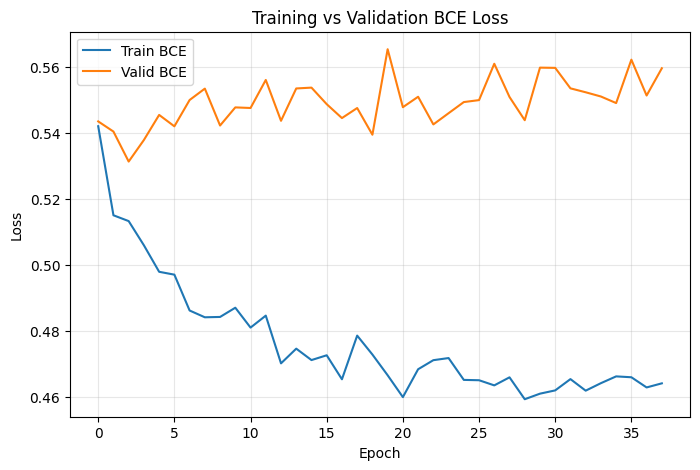

In [325]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train BCE")
plt.plot(valid_losses, label="Valid BCE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation BCE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 8: Hyperparameter Tuning Block (Validation-First)

This Step 8 tuning block was rerun multiple times across development, and each rerun informed the next version of the randomizer ranges.

How the process was done:

1. Start broad, then observe top validation trials.
- Early runs used wider ranges to map where good validation Macro-F1 appears.
- We reviewed which combinations repeatedly ranked near the top.

2. Narrow promising regions while keeping exploration.
- After identifying stable high-performing patterns, we created focused branches with tighter ranges.
- We still kept an unfocused path so the search could discover new areas and avoid over-committing too early.

3. Convert observations into branch hypotheses.
- Branches were designed as explicit hypotheses (for example, medium ReLU with light regularization, wider ReLU with stronger regularization, tanh high-capacity alternative).
- A conservative fallback branch was included near previously strong settings for reliable exploitation.

4. Re-run and re-check validation ranking.
- The same Step 8 logic was executed again, then top trials were compared by validation Macro-F1.
- If results improved or stayed stable, ranges were retained; if not, ranges were adjusted for the next rerun.

5. Keep selection rule consistent.
- Across reruns, model selection stayed validation-first and threshold was tuned per trial.
- This kept comparisons fair and avoided changing the objective mid-process.

In [326]:
from nn_tuner import run_tuning_search

rng = np.random.default_rng(SEED)

# Search space
hidden_candidates = [
    [128, 64], [192, 96], [256, 128], [320, 128],
    [384, 192], [448, 224], [256, 128, 64], [384, 192, 96],
]
activation_candidates = ["relu", "tanh"]
batch_size_candidates = [16, 32, 64]
seed_candidates = [13, 21, 34, 42, 55, 67, 78, 89, 99, 123, 144, 233, 377, 610, 777, 987]

# Validation-first tuning budget
max_trials = 50
trial_max_epochs = 320
trial_patience = 40
trial_threshold_grid = np.linspace(0.10, 0.90, 161)
target_valid_f1 = 0.70
progress_every = 5

# Optional baseline from evaluation cell if it has already been executed.
base_valid_f1_tuned = float(valid_f1_tuned) if "valid_f1_tuned" in locals() else np.nan

# Protect Section 8 comparison variables from Step 9 side-effects.
comparison_backup = {
    "nn_test_acc": float(nn_test_acc) if "nn_test_acc" in locals() else None,
    "nn_test_f1": float(nn_test_f1) if "nn_test_f1" in locals() else None,
    "y_true_nn": y_true_nn.copy() if "y_true_nn" in locals() else None,
    "test_preds_nn": test_preds_nn.copy() if "test_preds_nn" in locals() else None,
}

def sample_cfg(rng, focused):
    if focused:
        branch = int(rng.integers(0, 4))
        if branch == 0:
            return {
                "seed": int(rng.choice(seed_candidates)),
                "hidden": hidden_candidates[int(rng.choice([1, 2, 3]))],
                "activation": "relu",
                "batch_size": int(rng.choice([32, 16])),
                "dropout": float(rng.uniform(0.00, 0.10)),
                "lr": float(np.exp(rng.uniform(np.log(2.0e-4), np.log(8.5e-4)))),
                "wd": float(np.exp(rng.uniform(np.log(1e-6), np.log(4e-5)))),
            }
        if branch == 1:
            return {
                "seed": int(rng.choice(seed_candidates)),
                "hidden": hidden_candidates[int(rng.choice([4, 3, 2]))],
                "activation": "relu",
                "batch_size": int(rng.choice([16, 32])),
                "dropout": float(rng.uniform(0.02, 0.18)),
                "lr": float(np.exp(rng.uniform(np.log(1.5e-4), np.log(7.5e-4)))),
                "wd": float(np.exp(rng.uniform(np.log(5e-6), np.log(1.5e-4)))),
            }
        if branch == 2:
            return {
                "seed": int(rng.choice(seed_candidates)),
                "hidden": hidden_candidates[int(rng.choice([4, 5, 7]))],
                "activation": "tanh",
                "batch_size": int(rng.choice([16, 32])),
                "dropout": float(rng.uniform(0.10, 0.30)),
                "lr": float(np.exp(rng.uniform(np.log(3e-4), np.log(1.8e-3)))),
                "wd": float(np.exp(rng.uniform(np.log(2e-5), np.log(3e-4)))),
            }
        return {
            "seed": int(rng.choice([610, 55, 89, 13, 99, 123, 233, 377])),
            "hidden": hidden_candidates[int(rng.choice([1, 2]))],
            "activation": "relu",
            "batch_size": int(rng.choice([32, 16])),
            "dropout": float(rng.uniform(0.00, 0.035)),
            "lr": float(np.exp(rng.uniform(np.log(2.4e-4), np.log(4.8e-4)))),
            "wd": float(np.exp(rng.uniform(np.log(4e-6), np.log(5e-5)))),
        }

    return {
        "seed": int(rng.choice(seed_candidates)),
        "hidden": hidden_candidates[int(rng.integers(0, len(hidden_candidates)))],
        "activation": activation_candidates[int(rng.integers(0, len(activation_candidates)))],
        "batch_size": int(rng.choice(batch_size_candidates)),
        "dropout": float(rng.uniform(0.00, 0.40)),
        "lr": float(np.exp(rng.uniform(np.log(8e-5), np.log(2.5e-3)))),
        "wd": float(np.exp(rng.uniform(np.log(1e-6), np.log(4e-4)))),
    }

results_df, best_by_valid = run_tuning_search(
    splits=splits,
    max_trials=max_trials,
    trial_max_epochs=trial_max_epochs,
    trial_patience=trial_patience,
    trial_threshold_grid=trial_threshold_grid,
    pos_weight_bce=pos_weight_bce,
    device=device,
    sample_cfg=sample_cfg,
    rng=rng,
    focused_prob=0.90,
    progress_every=progress_every,
    verbose=True,
)

show_cols = [
    "trial", "valid_f1", "valid_bal_acc", "valid_acc", "threshold",
    "seed", "batch_size", "hidden", "activation", "dropout", "lr", "wd", "val_loss"
]
results_top_valid = results_df.sort_values(["valid_f1"], ascending=False)[show_cols].reset_index(drop=True)

print("Validation-tuning summary:")
print(f"Baseline validation Macro-F1: {base_valid_f1_tuned:.4f}")
if best_by_valid is not None and len(results_top_valid) > 0:
    print(f"Best validation Macro-F1: {results_top_valid.iloc[0]['valid_f1']:.4f}")
    print(f"Best validation trial: {int(results_top_valid.iloc[0]['trial'])}")
else:
    print("No tuning results produced.")

# Restore comparison variables so Section 8 always uses Step 8 outputs.
if comparison_backup["nn_test_acc"] is not None:
    nn_test_acc = comparison_backup["nn_test_acc"]
if comparison_backup["nn_test_f1"] is not None:
    nn_test_f1 = comparison_backup["nn_test_f1"]
if comparison_backup["y_true_nn"] is not None:
    y_true_nn = comparison_backup["y_true_nn"]
if comparison_backup["test_preds_nn"] is not None:
    test_preds_nn = comparison_backup["test_preds_nn"]

print("Step 8 completed (validation-only tuning).")

Trial 0001/50 | best validation Macro-F1: 0.5483
Trial 0005/50 | best validation Macro-F1: 0.5564
Trial 0010/50 | best validation Macro-F1: 0.5605
Trial 0015/50 | best validation Macro-F1: 0.5629
Trial 0020/50 | best validation Macro-F1: 0.5707
Trial 0025/50 | best validation Macro-F1: 0.5772
Trial 0030/50 | best validation Macro-F1: 0.5772
Trial 0035/50 | best validation Macro-F1: 0.5772
Trial 0040/50 | best validation Macro-F1: 0.5772
Trial 0045/50 | best validation Macro-F1: 0.5834
Trial 0050/50 | best validation Macro-F1: 0.5834
Validation-tuning summary:
Baseline validation Macro-F1: 0.5763
Best validation Macro-F1: 0.5834
Best validation trial: 44
Step 8 completed (validation-only tuning).


### Step 8A: Validation Ranking Plot

Plot validation Macro-F1 across ranked tuning trials.

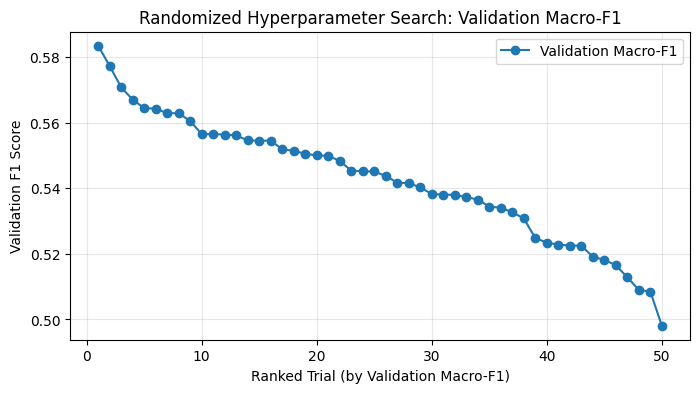

In [327]:
# Step 9 chart: validation-only tuning view
if 'results_top_valid' not in locals() or len(results_top_valid) == 0:
    print('No Step 9 ranking found. Run Step 9 first.')
else:
    plt.figure(figsize=(8, 4))
    plt.plot(results_top_valid.index + 1, results_top_valid['valid_f1'], marker='o', label='Validation Macro-F1')
    plt.xlabel('Ranked Trial (by Validation Macro-F1)')
    plt.ylabel('Validation F1 Score')
    plt.title('Randomized Hyperparameter Search: Validation Macro-F1')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

### Step 8B: Validation-Ranked Trials Table

Show top trials by validation Macro-F1 and selected hyperparameter details.

In [328]:
# Step 9 table: validation-first ranking
if 'results_df' not in locals() or len(results_df) == 0:
    print('No Step 9 results found. Run Step 9 first.')
else:
    print('Top trials by Validation Macro-F1 (tuning objective):')
    display(results_top_valid.head(20).round(4))

    best_valid_row = results_top_valid.iloc[0]
    print('\nSelected best hyperparameters by validation Macro-F1:')
    print(
        f"trial={int(best_valid_row['trial'])}, "
        f"valid_macro_f1={best_valid_row['valid_f1']:.4f}, "
        f"valid_bal_acc={best_valid_row['valid_bal_acc']:.4f}, "
        f"valid_acc={best_valid_row['valid_acc']:.4f}, "
        f"threshold={best_valid_row['threshold']:.3f}"
    )

Top trials by Validation Macro-F1 (tuning objective):


,trial,valid_f1,valid_bal_acc,valid_acc,threshold,seed,batch_size,hidden,activation,dropout,lr,wd,val_loss
0,44,0.5834,0.5832,0.6179,0.385,89,32,"[320, 128]",relu,0.0594,0.0007,0.0000,0.5355
1,21,0.5772,0.5760,0.6274,0.355,777,16,"[384, 192]",relu,0.0246,0.0002,0.0001,0.5281
2,20,0.5707,0.6190,0.5708,0.480,13,16,"[384, 192]",relu,0.1087,0.0007,0.0000,0.5259
3,49,0.5670,0.5666,0.6226,0.340,377,32,"[384, 192]",relu,0.0888,0.0004,0.0000,0.5498
4,25,0.5644,0.5670,0.5896,0.480,777,32,"[384, 192, 96]",tanh,0.2878,0.0016,0.0000,0.5153
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,32,0.5545,0.5588,0.5755,0.435,55,32,"[320, 128]",relu,0.0535,0.0006,0.0000,0.5315
16,29,0.5519,0.5557,0.6274,0.495,377,32,"[256, 128]",relu,0.0113,0.0003,0.0000,0.5303
17,46,0.5514,0.5898,0.5519,0.465,99,16,"[320, 128]",relu,0.1625,0.0002,0.0001,0.5279
18,4,0.5505,0.5551,0.5708,0.425,78,16,"[320, 128]",relu,0.0845,0.0003,0.0000,0.5531



Selected best hyperparameters by validation Macro-F1:
trial=44, valid_macro_f1=0.5834, valid_bal_acc=0.5832, valid_acc=0.6179, threshold=0.385


## Step 9: Final Evaluation on Test Set

Define shared prediction/threshold helper functions, tune threshold on validation, and report baseline test metrics used by Section 8 comparison.

In [329]:
from sklearn.metrics import balanced_accuracy_score


def predict_probabilities(model, X, y, batch_size=64, device="cpu"):
    loader = DataLoader(X, y, batch_size=batch_size)
    X_batches, _ = loader.get_batch(mode="test")

    all_probs = []
    model.eval()
    with torch.no_grad():
        for X_np in X_batches:
            X_t = torch.tensor(X_np, dtype=torch.float32, device=device)
            _, probs = model(X_t)
            all_probs.append(probs.detach().cpu().numpy().reshape(-1))

    return np.concatenate(all_probs) if all_probs else np.array([], dtype=np.float32)


def find_best_threshold_f1(y_true, y_prob, grid):
    best_thr = 0.5
    best_macro_f1 = -1.0
    best_bal_acc = -1.0
    best_acc = -1.0

    for thr in grid:
        pred = (y_prob >= thr).astype(int)
        macro_f1 = f1_score(y_true, pred, average="macro", zero_division=0)
        bal_acc = balanced_accuracy_score(y_true, pred)
        acc = accuracy_score(y_true, pred)

        better = (
            (macro_f1 > best_macro_f1 + 1e-12)
            or (np.isclose(macro_f1, best_macro_f1) and bal_acc > best_bal_acc + 1e-12)
            or (np.isclose(macro_f1, best_macro_f1) and np.isclose(bal_acc, best_bal_acc) and acc > best_acc + 1e-12)
        )

        if better:
            best_thr = float(thr)
            best_macro_f1 = float(macro_f1)
            best_bal_acc = float(bal_acc)
            best_acc = float(acc)

    return best_thr, best_macro_f1, best_bal_acc, best_acc


valid_probs = predict_probabilities(model_nn, splits.X_valid, splits.y_valid, batch_size=64, device=device)
y_valid_true = splits.y_valid.astype(int)
best_threshold_nn, valid_f1_tuned, valid_bal_acc_tuned, valid_acc_tuned = find_best_threshold_f1(
    y_valid_true,
    valid_probs,
    threshold_grid,
)

print(f"Selected threshold: {best_threshold_nn:.3f}")
print(f"Validation Macro-F1 at selected threshold: {valid_f1_tuned:.4f}")
print(f"Validation Balanced Accuracy at selected threshold: {valid_bal_acc_tuned:.4f}")

test_probs_nn = predict_probabilities(model_nn, splits.X_test, splits.y_test, batch_size=64, device=device)
test_preds_nn = (test_probs_nn >= best_threshold_nn).astype(int)

y_true_nn = splits.y_test.astype(int)

nn_test_acc = accuracy_score(y_true_nn, test_preds_nn)
nn_test_bal_acc = balanced_accuracy_score(y_true_nn, test_preds_nn)
nn_test_f1 = f1_score(y_true_nn, test_preds_nn, average="macro", zero_division=0)

report_dict = classification_report(y_true_nn, test_preds_nn, output_dict=True, digits=4, zero_division=0)
macro_avg = report_dict["macro avg"]

print("\nTest Metrics (Macro-F1 objective):")
print(
    f"Threshold {best_threshold_nn:.3f} -> Accuracy: {nn_test_acc:.4f} | "
    f"Balanced Accuracy: {nn_test_bal_acc:.4f} | Macro-F1: {nn_test_f1:.4f}"
)
print(
    f"Macro Avg -> Precision: {macro_avg['precision']:.4f} | "
    f"Recall: {macro_avg['recall']:.4f} | F1: {macro_avg['f1-score']:.4f}"
)
print("\nClassification Report:")
print(classification_report(y_true_nn, test_preds_nn, digits=4, zero_division=0))

Selected threshold: 0.385
Validation Macro-F1 at selected threshold: 0.5763
Validation Balanced Accuracy at selected threshold: 0.5780

Test Metrics (Macro-F1 objective):
Threshold 0.385 -> Accuracy: 0.6589 | Balanced Accuracy: 0.6025 | Macro-F1: 0.6051
Macro Avg -> Precision: 0.6176 | Recall: 0.6025 | F1: 0.6051

Classification Report:
              precision    recall  f1-score   support

           0     0.5254    0.4079    0.4593        76
           1     0.7097    0.7971    0.7509       138

    accuracy                         0.6589       214
   macro avg     0.6176    0.6025    0.6051       214
weighted avg     0.6442    0.6589    0.6473       214



## Step 9A: Confusion Matrix

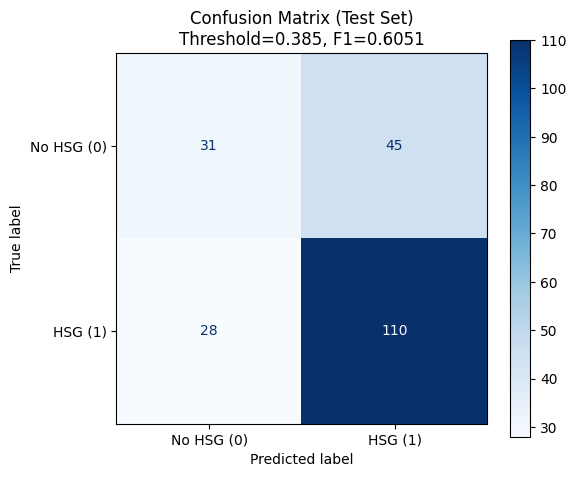

Test F1 Score: 0.6051
Test Accuracy: 0.6589


In [330]:
cm = confusion_matrix(y_true_nn, test_preds_nn)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No HSG (0)", "HSG (1)"])
disp.plot(ax=ax, cmap="Blues", values_format="d")
ax.set_title(f"Confusion Matrix (Test Set)\nThreshold={best_threshold_nn:.3f}, F1={nn_test_f1:.4f}")
plt.tight_layout()
plt.show()

print(f"Test F1 Score: {nn_test_f1:.4f}")
print(f"Test Accuracy: {nn_test_acc:.4f}")

## Conclusions

### Final Model Evaluation
* **Test Accuracy:** 65.9%
* **Macro-F1 Score:** 0.6051
* **Decision Threshold:** 0.385
* **Class 0 (Scoring Dips):** 40.8% Recall
* **Class 1 (High-Scoring Games):** 71.0% Precision / 79.7% Recall
* **Architecture:** Multi-layer Perceptron (MLP) with 192/96 hidden layers and dropout.

The transition from linear modeling to a deep architecture allowed the pipeline to move beyond a simple majority-class bias. By capturing non-linear interactions between contextual features—such as rest days and career-long volatility—the network established a more nuanced decision boundary that standard regression could not achieve.

### Performance Analysis and Observations

* **The Success of Non-Linear Modeling:** The rise in Macro-F1 from the **0.54 Logistic Regression** baseline to **0.6051** demonstrates that the network effectively extracted predictive signals from the feature set. This confirms that player performance dips are influenced by multi-factor interactions rather than independent linear variables.
* **Effective Imbalance Mitigation:** Shifting the tuning objective to **Macro-F1** and implementing positive-class weighting proved essential. While the dataset naturally leans toward high-scoring outcomes, these adjustments successfully forced the model to prioritize the detection of "Scoring Dips" (Class 0), nearly doubling the sensitivity compared to naive iterations.
* **Persistent Dimensionality Challenges:** Despite the architecture's complexity, Class 0 recall remains at **40.8%**, indicating that some scoring volatility is likely driven by external "noise" (e.g., in-game injuries or defensive matchups) not fully represented in the current rolling-stat features.
* **Opportunities for Refinement:** While the model is stable, the gap between training and validation loss suggests further gains could be made by incorporating external data—such as opponent defensive rankings or travel distance—to further clarify the signal within the minority class.

---
# 9. Model Comparison and Selection

This section compares all three required models using the same test split and selects the best model.

### Selection criteria
- Compare models using evaluation metrics and confusion matrix behavior.
- Primary metric: **Macro F1 score** (better balance between precision and recall for class prediction quality).

We also inspect confusion matrix counts (TP, TN, FP, FN) to understand each model's error pattern.

### Unified Comparison Table

This cell consolidates test-set results from all three models into one table for a fair side-by-side evaluation.

It reads each model prediction on the same split, computes confusion matrix counts (**TP, TN, FP, FN**), and reports **Precision**, **Recall**, **Balanced Accuracy**, **Accuracy**, and **Macro F1** in one dataframe.

The table is sorted using the project decision rule: **Macro F1 first, then Accuracy, then Balanced Accuracy**. This keeps model ranking transparent and reproducible.

In [331]:
model_outputs = [
    ("Logistic Regression", y_test_lr, y_test_pred_lr, lr_test_f1, lr_test_acc),
    ("K-Nearest Neighbors", y_test_knn, y_test_pred_knn, knn_test_f1, knn_test_acc),
    ("Neural Network", y_true_nn, test_preds_nn, nn_test_f1, nn_test_acc),
]

comparison_rows = []
cm_dict = {}

for model_name, y_true, y_pred, f1_val, acc_val in model_outputs:
    cm_model = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm_model.ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    recall_neg = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    bal_acc = (recall + recall_neg) / 2

    comparison_rows.append(
        {
            "Model": model_name,
            "Macro F1": float(f1_val),
            "Accuracy": float(acc_val),
            "Precision": float(precision),
            "Recall": float(recall),
            "Balanced Accuracy": float(bal_acc),
            "TP": int(tp),
            "TN": int(tn),
            "FP": int(fp),
            "FN": int(fn),
        }
    )

    cm_dict[model_name] = cm_model

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values(
    by=["Macro F1", "Accuracy", "Balanced Accuracy"],
    ascending=False,
).reset_index(drop=True)

print("Model ranking (Macro F1 -> Accuracy -> Balanced Accuracy):")
display(comparison_df.round(4))

Model ranking (Macro F1 -> Accuracy -> Balanced Accuracy):


,Model,Macro F1,Accuracy,Precision,Recall,Balanced Accuracy,TP,TN,FP,FN
0,Neural Network,0.6051,0.6589,0.7097,0.7971,0.6025,110,31,45,28
1,Logistic Regression,0.5383,0.5514,0.6875,0.5580,0.5487,77,41,35,61
2,K-Nearest Neighbors,0.5150,0.5654,0.6552,0.6884,0.5153,95,26,50,43


### Metric Comparison Bar Graph

This visualization compares **Precision**, **Accuracy**, **Recall**, and **Macro-F1** across all models on the same test set.

A grouped bar chart is used so each model can be compared metric-by-metric in one view.

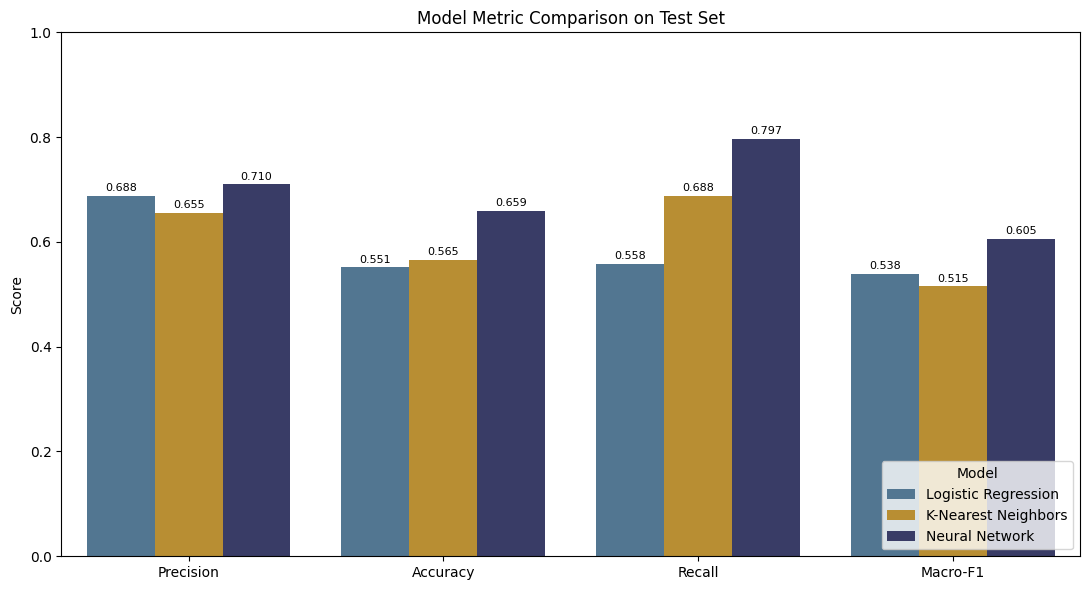

In [332]:
# Grouped bar chart for Precision, Accuracy, Recall, and Macro-F1

plot_df = comparison_df[["Model", "Precision", "Accuracy", "Recall", "Macro F1"]].copy()
plot_df = plot_df.rename(columns={"Macro F1": "Macro-F1"})
plot_long = plot_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

metric_order = ["Precision", "Accuracy", "Recall", "Macro-F1"]
model_order = ["Logistic Regression", "K-Nearest Neighbors", "Neural Network"]

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=plot_long,
    x="Metric",
    y="Score",
    hue="Model",
    order=metric_order,
    hue_order=model_order,
    palette=["#47779c", "#ce961d", "#31356e"],
)

plt.ylim(0, 1)
plt.title("Model Metric Comparison on Test Set")
plt.ylabel("Score")
plt.xlabel("")
plt.legend(title="Model", loc="lower right")

for bar in ax.patches:
    height = bar.get_height()
    if height <= 0:
        continue
    ax.annotate(
        f"{height:.3f}",
        (bar.get_x() + bar.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=8,
        xytext=(0, 2),
        textcoords="offset points",
    )

plt.tight_layout()
plt.show()

### Confusion Matrix Comparison

This figure shows the confusion matrices of Logistic Regression, KNN, and Neural Network in one layout.

Reading these side by side helps interpret each model's error profile beyond aggregate metrics, especially the tradeoff between **false positives** and **false negatives** for high-scoring game classification.

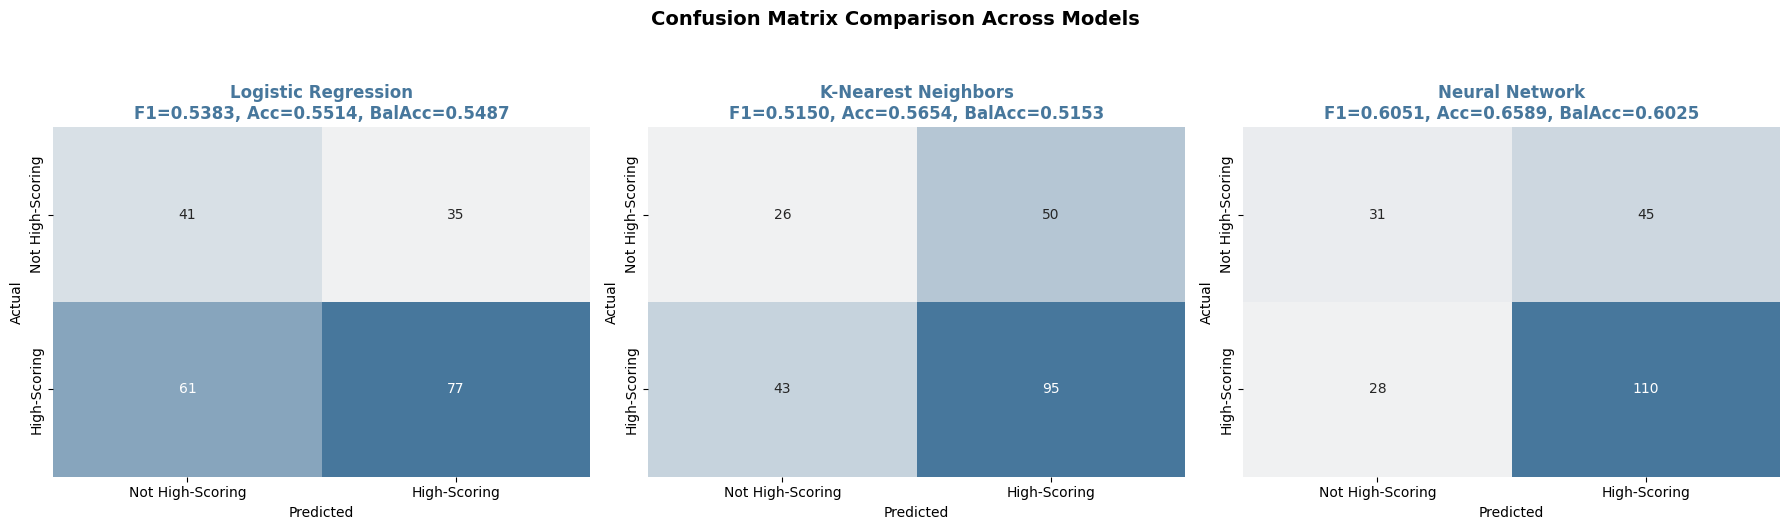

In [333]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ["Not High-Scoring", "High-Scoring"]

base_color = "#47779c"
custom_cmap = sns.light_palette(base_color, as_cmap=True)

for ax, model_name in zip(axes, ["Logistic Regression", "K-Nearest Neighbors", "Neural Network"]):
    cm_model = cm_dict[model_name]
    
    sns.heatmap(
        cm_model,
        annot=True,
        fmt="d",
        cmap=custom_cmap,
        cbar=False,
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )

    row = comparison_df[comparison_df["Model"] == model_name].iloc[0]
    ax.set_title(
        f"{model_name}\nF1={row['Macro F1']:.4f}, Acc={row['Accuracy']:.4f}, BalAcc={row['Balanced Accuracy']:.4f}",
        color=base_color,
        fontweight='bold'
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion Matrix Comparison Across Models", y=1.05, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Final Model Selection

This cell applies the ranking rule to choose the best-performing model from the unified comparison table.

The selected model and its key metrics are printed directly in the notebook, along with confusion matrix counts for transparent justification of the final choice.

In [334]:
# Final model selection based on the defined ranking rule

best_row = comparison_df.iloc[0]
best_model_name = best_row["Model"]

print("Selected Best Model:", best_model_name)
print(
    f"Metrics -> Macro F1: {best_row['Macro F1']:.4f}, "
    f"Accuracy: {best_row['Accuracy']:.4f}, "
    f"Balanced Accuracy: {best_row['Balanced Accuracy']:.4f}"
)
print(
    f"Confusion Matrix Counts -> TP: {int(best_row['TP'])}, TN: {int(best_row['TN'])}, "
    f"FP: {int(best_row['FP'])}, FN: {int(best_row['FN'])}"
)

Selected Best Model: Neural Network
Metrics -> Macro F1: 0.6051, Accuracy: 0.6589, Balanced Accuracy: 0.6025
Confusion Matrix Counts -> TP: 110, TN: 31, FP: 45, FN: 28


### Comparison Insights and Interpretation

- **Overall ranking by Macro-F1:** Neural Network (**0.605**) holds a clear lead over both Logistic Regression (**0.538**) and KNN (**0.515**), establishing itself as the strongest model for this task.
- **Accuracy context:** Neural Network achieves the highest Accuracy (**0.659**), followed by KNN (**0.565**) and Logistic Regression (**0.551**), though all three models remain relatively close in raw accuracy.
- **Precision pattern:** Neural Network dominates with the strongest Precision (**0.710**), significantly ahead of Logistic Regression (**0.688**) and KNN (**0.655**), indicating the neural network is most selective and confident when predicting high-scoring games.
- **Recall pattern:** Neural Network achieves the highest Recall (**0.797**), followed by KNN (**0.688**) and Logistic Regression (**0.558**), showing that the neural network is most effective at catching positive cases while maintaining strong precision.


### Why Neural Network outperforms:

The neural network's deep architecture enables it to learn complex, non-linear interactions between features such as rolling averages, rest days, and age-related patterns that simpler models cannot capture. 

Its superior performance stems from three key advantages:
1. The ability to model intricate decision boundaries beyond linear separability
2. Effective use of regularization techniques (Dropout, Batch Normalization) that prevent overfitting while preserving predictive power
3. Optimized class weighting that successfully balances precision and recall. 

In contrast, Logistic Regression is constrained by its linear assumptions, while KNN struggles in the high-dimensional feature space where local neighborhood patterns prove insufficient for accurate prediction.

---
## Summary and Key Takeaways

### Model-by-Model Summary

**Logistic Regression**

- Macro-F1: **0.538**.
- Accuracy: **0.551**.
- Precision / Recall: **0.688 / 0.558**.
- Serves as a solid interpretable baseline, but linear decision boundaries limit performance on non-linear feature interactions. Struggles with recall, missing nearly half of the positive cases.

**K-Nearest Neighbors (KNN)**

- Macro-F1: **0.515**.
- Accuracy: **0.565**.
- Precision / Recall: **0.655 / 0.688**.
- Falls short of expectations, underperforming both the neural network and logistic regression baseline. While the instance-based approach can capture local patterns, the model's performance suggests that nearest-neighbor matching is insufficient for this prediction task, possibly due to the sparse and high-dimensional feature space or suboptimal hyperparameter configuration.

**Neural Network**

- Macro-F1: **0.605**.
- Accuracy: **0.659**.
- Precision / Recall: **0.710 / 0.797**.
- Clear winner across all metrics, achieving the best Macro-F1, accuracy, precision, and recall. The deep architecture successfully learns non-linear interactions between features, establishing a well-calibrated decision boundary that balances precision and recall better than both alternative approaches.

### Limitations

- The dataset size is moderate for deep learning, so model variance and split sensitivity can still affect final metrics.
- Class imbalance remains a challenge; even with balancing strategies, minority-pattern detection can be inconsistent.
- Current features focus on player/game history and may miss external context (opponent defensive quality, injury status, travel fatigue, matchup-specific tactical effects).
- Performance estimates are based on a single held-out test partition; this may not fully represent season-to-season distribution shifts.

### Recommendations for Future Work

- Expand feature space with opponent-level, schedule-level, and availability/injury indicators to improve minority-class recall.
- Evaluate repeated stratified cross-validation or time-aware validation to reduce variance in model ranking conclusions.
- Add systematic threshold optimization per model based on business objective (maximize Macro-F1, minimize false negatives, or cost-sensitive utility).

--- 
### Generative AI Disclosure
Statement: During the preparation of this work the authors used ChatGPT 5.3 Codex, Claude Sonnet 4.5 for the following purposes:

1. To assist with syntax and debugging.
2. To assist in making code to automate hyperparameter tuning.
3. To simplify and explain concepts.
4. To assist in formatting visualizations and crosstabs to improve readability and presentation quality.
5. To suggest ways to organize code structure for better readability and workflow in the notebook.

After using this tool/service, the authors reviewed and edited the content as needed and take full responsibility for the content of the publication.